# MILPÍN AgTech — XGBoost v4.0 · Optimización Operacional
## Consumo Hídrico Agrícola · Valle del Yaqui, Sonora — DR-041, Módulo 3

**KPI central:** reducir consumo 8,000 → 6,000 m³/ha/ciclo (ahorro objetivo 25%)  
**Tarifa baseline:** $1.68 MXN/m³ (CFE 9-CU, bombeo 80 m)

| # | Mejora v4 | Descripción |
|---|-----------|-------------|
| 1 | Modelos por cultivo | XGBRegressor independiente — reduce mezcla de distribuciones |
| 2 | Optuna bayesiano | Búsqueda por cultivo optimizando **RMSE operacional** (no global) |
| 3 | Evaluación operacional | RMSE/MAE exclusivo en 6k–10k m³/ha — rango del KPI |
| 4 | Log-transform | `log(target)` → reduce heterocedasticidad |
| 5 | Pesos de muestra | 3× en rango operacional — gradiente dirigido al rango de interés |
| 6 | Dashboard comparativo | Global vs por cultivo vs log-transform + impacto económico |

**Stack:** XGBoost 3.x · scikit-learn · Optuna · numpy · pandas · matplotlib

In [2]:
# ═══════════════════════════════════════════════════════════════════
# MILPÍN — Auto-guardado en ML/images/
# Generado por ML/patch_notebooks.py — NO editar manualmente.
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import sys as _sys
import re  as _re
import atexit as _atexit

# ── Directorio de salida ─────────────────────────────────────────────────────
_here = Path().resolve()
IMAGES_DIR = (
    _here.parent / "images"
    if _here.name == "experiments"
    else _here / "ML" / "images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Parche matplotlib: auto-save en plt.show() + redirigir plt.savefig ───────
import matplotlib.pyplot   as _plt
import matplotlib.figure   as _mpl_fig

_saved_fig_ids  = set()
_auto_fig_count = [0]
_orig_plt_show    = _plt.show
_orig_plt_savefig = _plt.savefig
_orig_fig_savefig = _mpl_fig.Figure.savefig

def _auto_fname(fig, n):
    title = (fig._suptitle.get_text() if fig._suptitle else "") or next(
        (ax.get_title() for ax in fig.get_axes() if ax.get_title()), "")
    stem = _re.sub(r"[^\w\-]", "_", title)[:50].strip("_").lower() if title else f"figura_{n:03d}"
    return f"{stem}.png"

def _patched_plt_savefig(fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    fig  = _plt.gcf()
    _orig_fig_savefig(fig, dest, *a, **kw)  # llama directo para evitar doble-parche
    _saved_fig_ids.add(id(fig))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_fig_savefig(self, fname, *a, **kw):
    dest = IMAGES_DIR / Path(str(fname)).name
    _orig_fig_savefig(self, dest, *a, **kw)
    _saved_fig_ids.add(id(self))
    print(f"  ✓ [imagen] {dest.name}")

def _patched_plt_show(*a, **kw):
    fig = _plt.gcf()
    if fig.get_axes() and id(fig) not in _saved_fig_ids:
        _auto_fig_count[0] += 1
        fname = _auto_fname(fig, _auto_fig_count[0])
        _orig_fig_savefig(fig, IMAGES_DIR / fname, dpi=150, bbox_inches="tight")
        print(f"  ✓ [auto-imagen] {fname}")
    _saved_fig_ids.discard(id(fig))
    _orig_plt_show(*a, **kw)

_plt.show               = _patched_plt_show
_plt.savefig            = _patched_plt_savefig
_mpl_fig.Figure.savefig = _patched_fig_savefig

# ── Parche pandas: auto-save DataFrames al mostrarse en Jupyter ─────────────
_df_count = [0]
try:
    import pandas as _pd
    _orig_df_repr_html = _pd.DataFrame._repr_html_

    def _patched_df_repr_html(self):
        _df_count[0] += 1
        stem = f"tabla_{_df_count[0]:03d}"
        self.to_csv(IMAGES_DIR / f"{stem}.csv", index=True, encoding="utf-8-sig")
        self.to_html(IMAGES_DIR / f"{stem}.html")
        print(f"  ✓ [tabla] {stem}.csv  ({len(self)} filas × {len(self.columns)} cols)")
        return _orig_df_repr_html(self)

    _pd.DataFrame._repr_html_ = _patched_df_repr_html
except Exception as _pd_err:
    print(f"  ! pandas hook: {_pd_err}")

# ── Capturar stdout → IMAGES_DIR/output_log.txt ──────────────────────────────
_log_path = IMAGES_DIR / "output_log.txt"
_log_file = open(_log_path, "w", encoding="utf-8")

class _Tee:
    def __init__(self, real, log):
        self._real = real
        self._log  = log
    def write(self, s):
        self._real.write(s)
        self._log.write(s)
    def flush(self):
        self._real.flush()
        self._log.flush()
    def __getattr__(self, attr):
        return getattr(self._real, attr)

_sys.stdout = _Tee(_sys.__stdout__, _log_file)
_atexit.register(lambda: (_log_file.flush(), _log_file.close()))

print(f"✓ IMAGES_DIR  → {IMAGES_DIR}")
print(f"✓ matplotlib  → auto-save en show() + redirigir savefig()")
print(f"✓ pandas      → auto-save DataFrames (CSV + HTML)")
print(f"✓ stdout      → {_log_path.name}")


## 0. Imports y configuración global

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, learning_curve as lc_sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print('[WARN] Optuna no disponible — pip install optuna')

# ── Parámetros globales ─────────────────────────────────────────────────────
# Ajusta N_SAMPLES y OPTUNA_TRIALS según tiempo disponible:
#   N_SAMPLES=50_000  + OPTUNA_TRIALS=10  → ~3 min  (prueba rápida)
#   N_SAMPLES=300_000 + OPTUNA_TRIALS=40  → ~35 min (recomendado)
#   N_SAMPLES=1_000_000+ OPTUNA_TRIALS=50 → ~2 h    (producción)
N_SAMPLES      = 1_000_000
SEED           = 42
AÑO_RANGO      = (2014, 2024)
TARIFA         = 1.68        # MXN/m³ — CFE 9-CU, bombeo 80m
HA_MOD3        = 5_000       # ha estimadas Módulo 3
BASELINE_AGUA  = 8_000       # m³/ha — consumo actual DR-041
OBJETIVO_AGUA  = 6_000       # m³/ha — meta KPI
RANGO_OP_MIN   = 6_000       # límite inferior rango operacional
RANGO_OP_MAX   = 10_000      # límite superior rango operacional
OPTUNA_TRIALS  = 40          # trials por cultivo
OPTUNA_N_HPO   = 20_000      # filas para HPO (velocidad)
PESO_OP        = 3.0         # peso muestras en rango operacional
CULTIVOS       = ['Maíz', 'Frijol', 'Algodón', 'Uva', 'Chile']

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.spines.top': False, 'axes.spines.right': False})
C_AGUA = '#2e7fb8'; C_REND = '#4caf6f'; C_WARN = '#e07b39'
C_DARK = '#1a2636'; C_BG   = '#f7f9fb'; C_LINE = '#d0d7e2'
CULT_COLORS = {'Maíz':'#e6a817','Frijol':'#8b5e3c','Algodón':'#7ab8d9',
               'Uva':'#9b59b6','Chile':'#e74c3c'}

print(f'XGBoost {xgb.__version__} · numpy {np.__version__}')
print(f'N_SAMPLES={N_SAMPLES:,} · SEED={SEED} · OPTUNA_TRIALS={OPTUNA_TRIALS}')

## 1. Generador de datos v3 — Alta diversidad estadística

### 1a. Configuraciones base (regiones, arquetipos, etapas Kc)

| Módulo | Diversidad añadida |
|--------|--------------------|
| 5 micro-regiones | Heterogeneidad espacial ET₀ / lluvia / salinidad / nivel freático |
| 4 arquetipos de agricultor | Comportamiento over-irrigación / riegos perdidos |
| Kc por etapa FAO-56 | Curva 4-etapas Allen et al. 1998 — Tabla 11 |
| ENSO + drift climático | No-estacionariedad inter-anual |
| Eventos extremos | Olas de calor, heladas, inundaciones, plagas, fallas de riego |
| Salinidad FAO-33 | Confusor independiente del estrés hídrico |
| Ascenso capilar | Interacción nivel freático × déficit |
| Ruido IoT | Error de medición sensor ET₀ (8%), pluviómetro (3%), humedad (5%) |

In [4]:
REGIONES_CONFIG = {
    'Norte':   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    'Sur':     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    'Centro':  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    'Oriente': dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    'Costero': dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}
FARMER_TYPES = {
    'conservador': dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    'eficiente':   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    'negligente':  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    'tecnificado': dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}
KC_STAGES = {
    'Maíz':    dict(kc_ini=0.30,kc_dev=0.70,kc_med=1.20,kc_fin=0.60,
                    f_ini=0.10,f_dev=0.30,f_med=0.50,f_fin=0.10),
    'Frijol':  dict(kc_ini=0.40,kc_dev=0.70,kc_med=1.15,kc_fin=0.55,
                    f_ini=0.10,f_dev=0.35,f_med=0.40,f_fin=0.15),
    'Algodón': dict(kc_ini=0.45,kc_dev=0.75,kc_med=1.20,kc_fin=0.60,
                    f_ini=0.08,f_dev=0.30,f_med=0.45,f_fin=0.17),
    'Uva':     dict(kc_ini=0.30,kc_dev=0.65,kc_med=0.85,kc_fin=0.45,
                    f_ini=0.15,f_dev=0.35,f_med=0.35,f_fin=0.15),
    'Chile':   dict(kc_ini=0.40,kc_dev=0.75,kc_med=1.05,kc_fin=0.80,
                    f_ini=0.12,f_dev=0.30,f_med=0.45,f_fin=0.13),
}
SAL_THRESH = {'Maíz':1.7,'Frijol':1.0,'Algodón':7.7,'Uva':1.5,'Chile':1.5}
SAL_SLOPE  = {'Maíz':12, 'Frijol':19, 'Algodón':5.2,'Uva':9.6,'Chile':14}
print('Configuraciones v3 cargadas: 5 regiones · 4 arquetipos · Kc 4-etapas · salinidad FAO-33')

### 1b. Función `generar_datos_v3` — 100% vectorizada

In [5]:
def generar_datos_v3(n=50_000, seed=42, ruido_factor=1.0, año_rango=(2014, 2024)):
    rng = np.random.default_rng(seed)
    SUELOS   = ['franco','franco-arcilloso','franco-arenoso','arcilloso']
    SISTEMAS = ['gravedad','aspersion','goteo','microaspersion']
    REGIONES = list(REGIONES_CONFIG.keys()); FARMERS = list(FARMER_TYPES.keys())
    CULT = {
        'Maíz':    dict(dias=(130,150),kc=0.847,ky=1.25,ym=10.5),
        'Frijol':  dict(dias=( 90,110),kc=0.838,ky=1.15,ym=2.5 ),
        'Algodón': dict(dias=(165,200),kc=0.869,ky=0.85,ym=4.0 ),
        'Uva':     dict(dias=(180,215),kc=0.786,ky=0.85,ym=25.0),
        'Chile':   dict(dias=(110,130),kc=0.868,ky=1.10,ym=35.0),
    }
    SUELO = {
        'franco':           dict(cc=0.30,pmp=0.16,ks_mmh=15),
        'franco-arcilloso': dict(cc=0.36,pmp=0.20,ks_mmh=6),
        'franco-arenoso':   dict(cc=0.24,pmp=0.12,ks_mmh=30),
        'arcilloso':        dict(cc=0.42,pmp=0.22,ks_mmh=3),
    }
    EFIC = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}

    ci = rng.integers(0,len(CULTIVOS),n); si = rng.integers(0,len(SUELOS),n)
    ri = rng.integers(0,len(SISTEMAS),n); gi = rng.integers(0,len(REGIONES),n)
    fi = rng.integers(0,len(FARMERS),n)
    cultivos=np.array(CULTIVOS)[ci]; suelos=np.array(SUELOS)[si]
    sistemas=np.array(SISTEMAS)[ri]; regiones=np.array(REGIONES)[gi]
    farmers=np.array(FARMERS)[fi];   años=rng.integers(año_rango[0],año_rango[1]+1,n)

    ky_arr=np.array([CULT[c]['ky'] for c in CULTIVOS])[ci]
    ym_arr=np.array([CULT[c]['ym'] for c in CULTIVOS])[ci]
    dmin=np.array([CULT[c]['dias'][0] for c in CULTIVOS])[ci]
    dmax=np.array([CULT[c]['dias'][1] for c in CULTIVOS])[ci]
    cc_arr=np.array([SUELO[s]['cc'] for s in SUELOS])[si]
    pmp_arr=np.array([SUELO[s]['pmp'] for s in SUELOS])[si]
    ks_arr=np.array([SUELO[s]['ks_mmh'] for s in SUELOS])[si]
    ef_arr=np.array([EFIC[s] for s in SISTEMAS])[ri]
    r_et0=np.array([REGIONES_CONFIG[r]['et0_bias'] for r in REGIONES])[gi]
    r_lluv=np.array([REGIONES_CONFIG[r]['lluvia_mult'] for r in REGIONES])[gi]
    r_sal=np.array([REGIONES_CONFIG[r]['sal_base'] for r in REGIONES])[gi]
    r_wt=np.array([REGIONES_CONFIG[r]['wt_m'] for r in REGIONES])[gi]
    r_elev=np.array([REGIONES_CONFIG[r]['elev_m'] for r in REGIONES])[gi]
    f_mu=np.array([FARMER_TYPES[f]['over_irr_mu'] for f in FARMERS])[fi]
    f_sd=np.array([FARMER_TYPES[f]['over_irr_sd'] for f in FARMERS])[fi]
    f_miss=np.array([FARMER_TYPES[f]['p_miss'] for f in FARMERS])[fi]

    area_ha=rng.uniform(5.0,80.0,n).round(2)
    doy=rng.integers(1,365,n)
    dias_ciclo=(dmin+rng.random(n)*(dmax-dmin)).astype(int)
    prof_raiz=rng.uniform(0.45,0.70,n).round(3)

    año_span=max(año_rango[1]-año_rango[0],1)
    año_norm=(años-año_rango[0])/año_span
    et0_drift=año_norm*0.022*año_span
    enso_vals=np.random.default_rng(seed+9999).normal(0,0.28,año_span+1)
    enso_arr=enso_vals[años-año_rango[0]]
    lluvia_enso=1.0+enso_arr*0.35

    et0_s=6.0+2.5*np.sin(2*np.pi*(doy-81)/365)
    et0_reg=np.where(enso_arr>0.15,et0_s*rng.uniform(1.05,1.28,n),
                                    et0_s*rng.uniform(0.88,1.05,n))
    et0_prom=np.clip(et0_reg+r_et0+et0_drift+rng.normal(0,0.55*ruido_factor,n),2.8,11.0).round(3)
    et0_max=np.clip(et0_prom*rng.uniform(1.15,1.65,n),et0_prom+0.3,12.5).round(3)

    es_verano=(doy>=152)&(doy<=273)
    lluvia_raw=np.where(es_verano,
                        rng.gamma(2.2,55.0,n)*r_lluv*lluvia_enso,
                        rng.gamma(0.9,18.0,n)*r_lluv*np.clip(0.7+0.3*lluvia_enso,0.3,1.5))
    lluvia=np.clip(lluvia_raw+rng.normal(0,4.0*ruido_factor,n),0,400).round(2)

    # Kc por etapa FAO-56 (Allen et al. 1998)
    pos_ciclo=rng.beta(1.5,1.5,n)
    kc_stage=np.full(n,0.7)
    for ci_k,cultivo in enumerate(CULTIVOS):
        mask=ci==ci_k
        if not mask.any(): continue
        s=KC_STAGES[cultivo]; pos=pos_ciclo[mask]
        f2=s['f_ini']+s['f_dev']; f3=f2+s['f_med']
        kc_stage[mask]=np.where(pos<s['f_ini'],s['kc_ini'],
                        np.where(pos<f2,s['kc_ini']+(s['kc_med']-s['kc_ini'])*(pos-s['f_ini'])/s['f_dev'],
                        np.where(pos<f3,s['kc_med'],
                            s['kc_med']+(s['kc_fin']-s['kc_med'])*(pos-f2-s['f_med'])/s['f_fin'])))
    kc_prom=np.clip(kc_stage+rng.normal(0,0.018*ruido_factor,n),0.22,1.30).round(3)

    sal_ec=np.clip(r_sal+rng.gamma(1.5,1.2,n)*ruido_factor,0.01,9.0).round(3)
    sal_th=np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl=np.array([SAL_SLOPE[c] for c in CULTIVOS])[ci]
    ks_sal=np.clip(1.0-sal_sl/100*np.maximum(0,sal_ec-sal_th),0.05,1.0)

    ola_calor=rng.random(n)<0.10*ruido_factor
    dias_calor=np.where(ola_calor,rng.integers(5,18,n),0)
    et0_extra=np.where(ola_calor,et0_prom*rng.uniform(0.22,0.55,n)*dias_calor/dias_ciclo,0.0)
    helada=(rng.random(n)<0.06*ruido_factor)&((doy>=300)|(doy<=60))
    f_helada=np.where(helada,rng.uniform(0.30,0.75,n),1.0)
    inundacion=(rng.random(n)<0.04*ruido_factor)&es_verano
    f_inund_a=np.where(inundacion,rng.uniform(1.10,1.40,n),1.0)
    f_inund_r=np.where(inundacion,rng.uniform(0.50,0.85,n),1.0)
    plaga=rng.random(n)<0.12*ruido_factor
    f_plaga=np.where(plaga,rng.uniform(0.60,0.96,n),1.0)
    falla=rng.random(n)<f_miss

    aporte_capilar=np.where(r_wt<3.5,
        np.clip((3.5-r_wt)*rng.uniform(0.4,1.8,n)*dias_ciclo/100,0,80),0.0).round(2)
    perc_frac=np.clip((1-ef_arr)*0.35+(ks_arr/30.0)*0.12+rng.uniform(0,0.06,n),0.02,0.38).round(4)

    etc_total=np.clip((et0_prom+et0_extra)*dias_ciclo*kc_prom,180,2800).round(2)
    hum_suelo=np.clip(cc_arr*0.85+rng.normal(0,0.028*ruido_factor,n),pmp_arr+0.01,cc_arr).round(4)
    deficit_prob=np.clip((1-ef_arr)*0.28*ruido_factor,0,0.38)
    deficit_hid=np.where(rng.random(n)<deficit_prob,rng.beta(1.2,3.5,n)*0.55,0.0).round(4)
    deficit_hid=np.where(falla,np.clip(deficit_hid+rng.uniform(0.08,0.32,n),0,0.65),deficit_hid)

    agua_disp=(cc_arr-pmp_arr)*prof_raiz*1000
    over_irr=np.clip(1.0+f_mu+rng.normal(0,f_sd,n),0.55,1.70)
    n_riegos=np.clip(
        np.maximum(1,np.round((etc_total-lluvia).clip(0)/(agua_disp*0.6)).astype(int)
                   +rng.integers(-1,2,n)),1,40)

    deficit_agua=np.maximum(0,etc_total-lluvia-aporte_capilar)
    vol_base=deficit_agua*10/ef_arr*over_irr*f_inund_a
    vol_iot=vol_base*np.where(rng.random(n)<0.04*ruido_factor,rng.uniform(0.85,1.15,n),1.0)
    vol_agua=np.clip(vol_iot+rng.normal(0,180*ruido_factor,n),1_200,28_000).round(2)

    ks_water=1.0-deficit_hid
    ya_frac=np.clip(1-ky_arr*(1-ks_water),0.05,1.0)
    rendimiento=np.clip(
        ym_arr*ya_frac*ks_sal*f_helada*f_plaga*f_inund_r*rng.normal(1.0,0.08*ruido_factor,n),
        0.2,ym_arr*1.2).round(3)

    return pd.DataFrame({
        'cultivo':cultivos,'tipo_suelo':suelos,'sistema_riego':sistemas,
        'region':regiones,'tipo_agricultor':farmers,
        'area_ha':area_ha,'dias_ciclo':dias_ciclo,'doy_inicio':doy,
        'capacidad_campo':cc_arr,'punto_marchitez':pmp_arr,'prof_raiz_m':prof_raiz,
        'et0_promedio_mmdia':et0_prom,'et0_maximo_mmdia':et0_max,
        'lluvia_total_mm':lluvia,'etc_total_mm':etc_total,'kc_promedio':kc_prom,
        'humedad_suelo_promedio':hum_suelo,'deficit_hidrico_frac':deficit_hid,
        'n_riegos':n_riegos,'volumen_agua_total_m3_ha':vol_agua,
        'rendimiento_real_ton_ha':rendimiento,
        'año':años,'año_norm':año_norm,'pos_ciclo_frac':pos_ciclo,
        'salinidad_ec_dsm':sal_ec,'ks_salinidad':ks_sal,
        'aporte_capilar_mm':aporte_capilar,'percolacion_frac':perc_frac,
        'ola_calor':ola_calor.astype(int),'helada':helada.astype(int),
        'inundacion':inundacion.astype(int),'plaga':plaga.astype(int),
        'falla_riego':falla.astype(int),'elev_parcela_m':r_elev,
    })

print('generar_datos_v3 lista — 10 módulos de complejidad, 100% vectorizada')

### 1c. Generar dataset y explorar distribución

In [6]:
t0 = time.time()
df = generar_datos_v3(n=N_SAMPLES, seed=SEED, ruido_factor=1.0, año_rango=AÑO_RANGO)
print(f'Generados {N_SAMPLES:,} ciclos en {time.time()-t0:.1f}s')
print(f'Columnas: {df.shape[1]} · Memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print()
print('Distribución volumen_agua_total_m3_ha por cultivo:')
display(df.groupby('cultivo')['volumen_agua_total_m3_ha'].agg(['mean','std','min','max']).round(0))

,mean,std,min,max
cultivo,,,,
Algodón,15961.0,6925.0,1200.0,28000.0
Chile,9165.0,4836.0,1200.0,28000.0
Frijol,8074.0,4387.0,1200.0,28000.0
Maíz,12097.0,6376.0,1200.0,28000.0
Uva,11451.0,6142.0,1200.0,28000.0


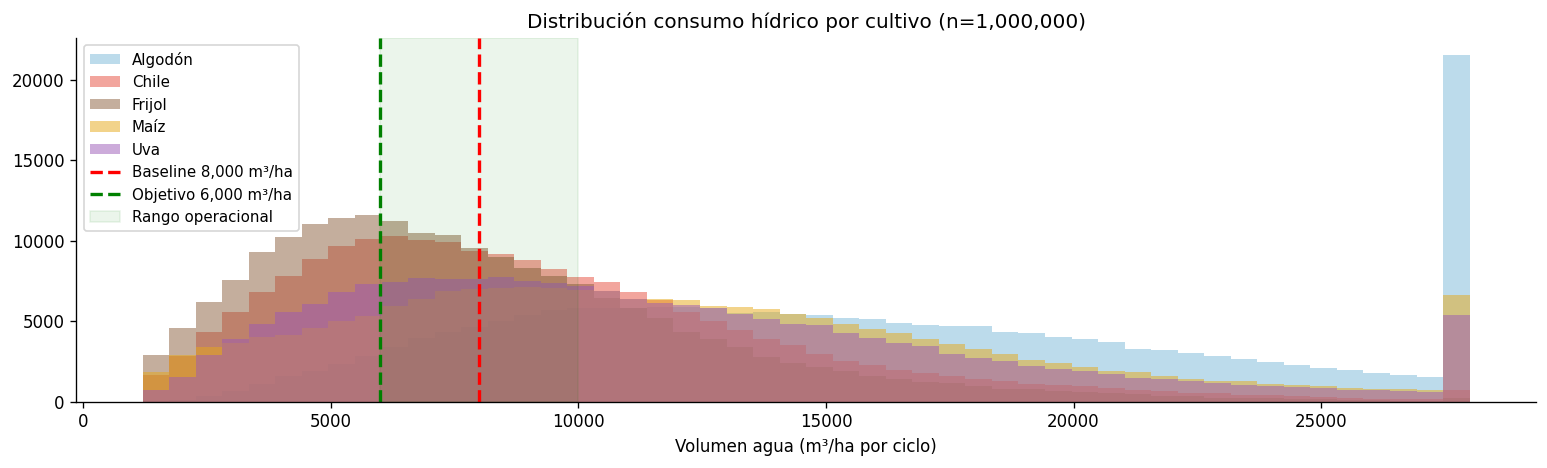

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
for cultivo, g in df.groupby('cultivo'):
    ax.hist(g['volumen_agua_total_m3_ha'], bins=50, alpha=0.50,
            label=cultivo, color=CULT_COLORS[cultivo])
ax.axvline(BASELINE_AGUA, color='red', lw=2, ls='--', label=f'Baseline {BASELINE_AGUA:,} m³/ha')
ax.axvline(OBJETIVO_AGUA, color='green', lw=2, ls='--', label=f'Objetivo {OBJETIVO_AGUA:,} m³/ha')
ax.axvspan(RANGO_OP_MIN, RANGO_OP_MAX, alpha=0.08, color='green', label='Rango operacional')
ax.set_xlabel('Volumen agua (m³/ha por ciclo)')
ax.set_title(f'Distribución consumo hídrico por cultivo (n={N_SAMPLES:,})')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## 2. Feature Engineering extendido (v4)

| Grupo | Features | Fuente |
|-------|----------|--------|
| v2 heredadas | `eto_x_dias`, `deficit_agua_mm`, `agua_disponible_mm`, `ky_cultivo`, `eficiencia_sistema`, `indice_estres_x_ky`, `ratio_demanda_suelo`, `doy_sin/cos` | v3 notebook |
| v3 heredadas | `et0_range`, `lluvia_etc_ratio`, `agua_efectiva_mm`, `kc_x_et0`, `ks_sal_x_deficit`, `capilar_sobre_etc`, `perc_x_efic` | v3 notebook |
| **v4 nuevas** | `demanda_neta_mm`, `vol_teorico_m3ha`, `ratio_real_teorico`, `et0_x_ks_sal`, `kc_pos_ciclo`, `dias_x_kc`, `estres_total`, `riesgo_extremo`, `et0_drift_x_año`, `prof_x_agua_disp` | **v4 — enfoque operacional** |

In [8]:
KY_MAP = {'Maíz':1.25,'Frijol':1.15,'Algodón':0.85,'Uva':0.85,'Chile':1.10}
EF_MAP = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
YM_MAP = {'Maíz':10.5,'Frijol':2.5,'Algodón':4.0,'Uva':25.0,'Chile':35.0}

# Features v2 (heredadas de v3 notebook)
df['eto_x_dias']         = df['et0_promedio_mmdia'] * df['dias_ciclo']
df['deficit_agua_mm']    = (df['etc_total_mm'] - df['lluvia_total_mm']).clip(lower=0)
df['agua_disponible_mm'] = (df['capacidad_campo'] - df['punto_marchitez']) * df['prof_raiz_m'] * 1000
df['ky_cultivo']         = df['cultivo'].map(KY_MAP)
df['eficiencia_sistema'] = df['sistema_riego'].map(EF_MAP)
df['rendimiento_maximo'] = df['cultivo'].map(YM_MAP)
df['indice_estres_x_ky'] = df['deficit_hidrico_frac'] * df['ky_cultivo']
df['ratio_demanda_suelo']= df['etc_total_mm'] / (df['agua_disponible_mm'] + 1)
df['doy_sin']            = np.sin(2 * np.pi * df['doy_inicio'] / 365)
df['doy_cos']            = np.cos(2 * np.pi * df['doy_inicio'] / 365)

# Features v3 (heredadas)
df['et0_range']          = df['et0_maximo_mmdia'] - df['et0_promedio_mmdia']
df['lluvia_etc_ratio']   = df['lluvia_total_mm'] / (df['etc_total_mm'] + 1)
df['agua_efectiva_mm']   = df['lluvia_total_mm'] * df['eficiencia_sistema']
df['kc_x_et0']           = df['kc_promedio'] * df['et0_promedio_mmdia']
df['ks_sal_x_deficit']   = df['ks_salinidad'] * df['deficit_hidrico_frac']
df['capilar_sobre_etc']  = df['aporte_capilar_mm'] / (df['etc_total_mm'] + 1)
df['perc_x_efic']        = df['percolacion_frac'] * df['eficiencia_sistema']

# Features v4 (nuevas — enfoque operacional)
df['demanda_neta_mm']    = (df['etc_total_mm'] - df['lluvia_total_mm'] - df['aporte_capilar_mm']).clip(lower=0)
df['vol_teorico_m3ha']   = df['demanda_neta_mm'] * 10 / df['eficiencia_sistema']
df['ratio_real_teorico'] = df['volumen_agua_total_m3_ha'] / (df['vol_teorico_m3ha'] + 1)
df['et0_x_ks_sal']       = df['et0_promedio_mmdia'] * df['ks_salinidad']
df['kc_pos_ciclo']       = df['kc_promedio'] * df['pos_ciclo_frac']
df['dias_x_kc']          = df['dias_ciclo'] * df['kc_promedio']
df['estres_total']       = df['deficit_hidrico_frac'] + (1 - df['ks_salinidad']) * 0.5
df['riesgo_extremo']     = (df['ola_calor'] + df['helada'] + df['inundacion']
                            + df['plaga'] + df['falla_riego'])
df['et0_drift_x_año']    = df['et0_promedio_mmdia'] * df['año_norm']
df['prof_x_agua_disp']   = df['prof_raiz_m'] * df['agua_disponible_mm']

DROP_COLS = ['volumen_agua_total_m3_ha', 'rendimiento_real_ton_ha', 'año']
n_feats = len([c for c in df.columns if c not in ['cultivo','tipo_suelo','sistema_riego',
               'region','tipo_agricultor'] + DROP_COLS])
print(f'Features numéricas: {n_feats} (v2: 9 + v3: 7 + v4: 10 + base: {n_feats-26})')

## 3. Preparación ML

**Splits:** 80% train · 10% validación (early stopping) · 20% test  
**Pesos de muestra:** 3× para muestras en rango operacional 6k–10k m³/ha  
**Encoding:** LabelEncoder para las 5 variables categóricas

In [9]:
CAT_COLS = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
TARGET   = 'volumen_agua_total_m3_ha'

le_dict = {}
df_enc  = df.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

FEAT_COLS = [c for c in df_enc.columns if c not in DROP_COLS + [TARGET]]
X = df_enc[FEAT_COLS]
y = df_enc[TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.10, random_state=SEED)

def calc_weights(y_series, w_op=PESO_OP, lo=RANGO_OP_MIN, hi=RANGO_OP_MAX):
    w = np.ones(len(y_series))
    w[(y_series >= lo) & (y_series <= hi)] = w_op
    return w

w_tr2 = calc_weights(y_tr2)

n_op = ((y_te >= RANGO_OP_MIN) & (y_te <= RANGO_OP_MAX)).sum()
print(f'Train: {len(X_tr2):,} | Val: {len(X_val):,} | Test: {len(X_te):,}')
print(f'Features: {len(FEAT_COLS)}')
print(f'Test en rango operacional ({RANGO_OP_MIN:,}–{RANGO_OP_MAX:,} m³/ha): {n_op:,} ({n_op/len(y_te)*100:.1f}%)')
print(f'Muestras con peso 3× en train: {int((w_tr2==PESO_OP).sum()):,} ({(w_tr2==PESO_OP).mean()*100:.1f}%)')

## 4. Funciones de evaluación operacional

### Métrica clave: Ahorro neto operacional

```
RMSE_op       = RMSE calculado solo sobre muestras en [6k–10k m³/ha]
Δobjetivo     = BASELINE_AGUA - OBJETIVO_AGUA = 8,000 - 6,000 = 2,000 m³/ha
ratio         = RMSE_op / Δobjetivo
Ahorro neto % = max(0, 1 - ratio) × 100
```

Un modelo con RMSE_op < 1,000 m³/ha → ahorro neto > 50%  
Un modelo con RMSE_op < 667 m³/ha → ahorro neto > 66.7% (invierte el donut v3)

In [10]:
def metricas_completas(y_true, y_pred, nombre, tarifa=TARIFA):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask_op = (y_true >= RANGO_OP_MIN) & (y_true <= RANGO_OP_MAX)
    y_op = y_true[mask_op]
    p_op = np.array(y_pred)[mask_op]
    mae_op  = mean_absolute_error(y_op, p_op) if len(y_op) > 0 else np.nan
    rmse_op = np.sqrt(mean_squared_error(y_op, p_op)) if len(y_op) > 0 else np.nan
    r2_op   = r2_score(y_op, p_op) if len(y_op) > 5 else np.nan
    err_rel = rmse_op / (BASELINE_AGUA - OBJETIVO_AGUA) if len(y_op) > 0 else np.nan
    ahorro_neto_pct = max(0, 1 - err_rel) * 100 if not np.isnan(err_rel) else np.nan
    print(f'{'─'*60}')
    print(f'  {nombre}')
    print(f'  Global  → MAE:{mae:>9.1f}  RMSE:{rmse:>9.1f}  R²:{r2:.4f}')
    print(f'  Operac. → MAE:{mae_op:>9.1f}  RMSE:{rmse_op:>9.1f}  R²:{r2_op:.4f}')
    print(f'  Error monetario (RMSE×tarifa): ${rmse*tarifa:,.0f} MXN/ha/ciclo')
    print(f'  Ratio RMSE_op / Δobj: {err_rel:.1%}  →  Ahorro neto: {ahorro_neto_pct:.1f}%')
    print(f'{'─'*60}')
    return {'nombre':nombre,'mae':mae,'rmse':rmse,'r2':r2,
            'mae_op':mae_op,'rmse_op':rmse_op,'r2_op':r2_op,
            'err_rel':err_rel,'ahorro_neto_pct':ahorro_neto_pct,'n_op':int(mask_op.sum())}

def rmse_por_rango(y_true, y_pred, bins=None):
    if bins is None:
        bins = [0, 4000, 6000, 8000, 10000, 14000, 20000, 30000]
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    labels = [f'{int(bins[i]/1000)}k–{int(bins[i+1]/1000)}k' for i in range(len(bins)-1)]
    rows = []
    for i in range(len(bins)-1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() < 5: continue
        rmse_v = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        rows.append({'rango':labels[i],'n':mask.sum(),'rmse':round(rmse_v,0),
                     'operacional':(bins[i] >= RANGO_OP_MIN and bins[i+1] <= RANGO_OP_MAX+4000)})
    return pd.DataFrame(rows)

print('Funciones de evaluación listas.')

## 5. Modelo Global — Baseline para comparación

Mismo esquema que v3: un único `XGBRegressor` para todos los cultivos.  
**Diferencia respecto a v3:** incluye `sample_weight` 3× en rango operacional.

In [11]:
params_global = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.10, reg_lambda=1.00,
    early_stopping_rounds=50, eval_metric='rmse',
    random_state=SEED, n_jobs=-1, verbosity=0,
)

t0 = time.time()
model_global = xgb.XGBRegressor(**params_global)
model_global.fit(X_tr2, y_tr2, sample_weight=w_tr2,
                  eval_set=[(X_val, y_val)], verbose=False)
pred_global = model_global.predict(X_te)
print(f'Entrenamiento: {time.time()-t0:.1f}s | Best iter: {model_global.best_iteration}')

met_global = metricas_completas(y_te.values, pred_global, 'GLOBAL — todos los cultivos')
df_rango_global = rmse_por_rango(y_te.values, pred_global)
print()
print('RMSE por rango — modelo global:')
display(df_rango_global.style.apply(lambda r: ['background-color: #d4f7d4' if r['operacional'] else '' for _ in r], axis=1))

,rango,n,rmse,operacional
0,0k–4k,17803,54.000000,False
1,4k–6k,25452,40.000000,False
2,6k–8k,28876,38.000000,True
3,8k–10k,27564,45.000000,True
4,10k–14k,42671,71.000000,True
5,14k–20k,34768,109.000000,False
6,20k–30k,22866,177.000000,False


## 6. Optuna — Búsqueda Bayesiana por Cultivo

**Función objetivo:** RMSE calculado **exclusivamente en el rango operacional** (6k–10k m³/ha)  
**Sampler:** TPE (Tree-structured Parzen Estimator) — eficiente en espacios de alta dimensión  
**Subsample:** 20k filas por cultivo para velocidad (~2 min/cultivo con 40 trials)

Hiperparámetros buscados:
- `max_depth` ∈ [3, 7]
- `learning_rate` ∈ [0.01, 0.15] (log-scale)
- `subsample` ∈ [0.65, 1.0]
- `colsample_bytree` ∈ [0.60, 1.0]
- `min_child_weight` ∈ [1, 10]
- `gamma` ∈ [0.0, 2.0]
- `reg_alpha` ∈ [0.001, 2.0] (log-scale)
- `reg_lambda` ∈ [0.5, 5.0] (log-scale)

In [12]:
PARAMS_DEFAULT = dict(
    n_estimators=1000, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.10, reg_lambda=1.00,
    early_stopping_rounds=30, eval_metric='rmse',
    random_state=SEED, n_jobs=-1, verbosity=0,
)
best_params_por_cultivo = {}

if HAS_OPTUNA:
    print(f'Optuna {OPTUNA_TRIALS} trials × {len(CULTIVOS)} cultivos — optimizando RMSE_op')
    print('─' * 60)
    for cultivo in CULTIVOS:
        mask_c = df['cultivo'] == cultivo
        X_c = df_enc.loc[mask_c, FEAT_COLS]
        y_c = df_enc.loc[mask_c, TARGET]
        n_hpo = min(OPTUNA_N_HPO, len(X_c))
        idx   = np.random.default_rng(SEED).choice(len(X_c), n_hpo, replace=False)
        X_hpo = X_c.iloc[idx]; y_hpo = y_c.iloc[idx]
        X_h_tr,X_h_val,y_h_tr,y_h_val = train_test_split(
            X_hpo, y_hpo, test_size=0.15, random_state=SEED)

        def objective(trial):
            p = {
                'n_estimators': 600,
                'max_depth':          trial.suggest_int('max_depth', 3, 7),
                'learning_rate':      trial.suggest_float('lr', 0.01, 0.15, log=True),
                'subsample':          trial.suggest_float('subsample', 0.65, 1.0),
                'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.60, 1.0),
                'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
                'gamma':              trial.suggest_float('gamma', 0.0, 2.0),
                'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 2.0, log=True),
                'reg_lambda':         trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
                'early_stopping_rounds': 20, 'eval_metric': 'rmse',
                'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
            }
            w_h = calc_weights(y_h_tr)
            m = xgb.XGBRegressor(**p)
            m.fit(X_h_tr, y_h_tr, sample_weight=w_h,
                  eval_set=[(X_h_val, y_h_val)], verbose=False)
            pred = m.predict(X_h_val)
            mask_op = (y_h_val.values >= RANGO_OP_MIN) & (y_h_val.values <= RANGO_OP_MAX)
            if mask_op.sum() < 10:
                return np.sqrt(mean_squared_error(y_h_val, pred))
            return np.sqrt(mean_squared_error(y_h_val.values[mask_op], pred[mask_op]))

        t0 = time.time()
        study = optuna.create_study(direction='minimize',
                                     sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
        bp = study.best_params
        best_params_por_cultivo[cultivo] = {
            'n_estimators': 1500, 'max_depth': bp['max_depth'],
            'learning_rate': bp['lr'], 'subsample': bp['subsample'],
            'colsample_bytree': bp['colsample_bytree'],
            'min_child_weight': bp['min_child_weight'],
            'gamma': bp.get('gamma', 0.0),
            'reg_alpha': bp['reg_alpha'], 'reg_lambda': bp['reg_lambda'],
            'early_stopping_rounds': 30, 'eval_metric': 'rmse',
            'random_state': SEED, 'n_jobs': -1, 'verbosity': 0,
        }
        print(f'  {cultivo:10s} → RMSE_op: {study.best_value:,.0f} m³/ha | '
              f'depth={bp["max_depth"]} lr={bp["lr"]:.4f} [{time.time()-t0:.0f}s]')
else:
    print('[INFO] Optuna no disponible — usando parámetros por defecto para todos los cultivos')
    for cultivo in CULTIVOS:
        best_params_por_cultivo[cultivo] = PARAMS_DEFAULT.copy()

## 7. Modelos por Cultivo

Cada cultivo tiene su propio `XGBRegressor` entrenado con:
- Hiperparámetros optimizados por Optuna (sección 6)
- Pesos 3× en rango operacional
- Early stopping sobre val-set del cultivo

Al finalizar se combinan en un **ensamble por cultivo** que cubre el test set completo.

In [13]:
models_por_cultivo = {}
mets_por_cultivo   = {}
preds_por_cultivo  = {}
rangos_por_cultivo = {}

for cultivo in CULTIVOS:
    mask_all = df['cultivo'] == cultivo
    mask_tr_ = X_tr.index.isin(df.index[mask_all])
    mask_te_ = X_te.index.isin(df.index[mask_all])
    X_c_tr = X_tr[mask_tr_]; y_c_tr = y_tr[mask_tr_]
    X_c_te = X_te[mask_te_]; y_c_te = y_te[mask_te_]
    X_c_tr2, X_c_val, y_c_tr2, y_c_val = train_test_split(
        X_c_tr, y_c_tr, test_size=0.10, random_state=SEED)
    w_c = calc_weights(y_c_tr2)
    params = best_params_por_cultivo.get(cultivo, PARAMS_DEFAULT).copy()
    t0 = time.time()
    m = xgb.XGBRegressor(**params)
    m.fit(X_c_tr2, y_c_tr2, sample_weight=w_c,
          eval_set=[(X_c_val, y_c_val)], verbose=False)
    pred_c = m.predict(X_c_te)
    print(f'{cultivo} (n_test={len(y_c_te):,} | best_iter={m.best_iteration} | {time.time()-t0:.1f}s)')
    met = metricas_completas(y_c_te.values, pred_c, f'  {cultivo}')
    models_por_cultivo[cultivo] = m
    mets_por_cultivo[cultivo]   = met
    preds_por_cultivo[cultivo]  = (y_c_te.values, pred_c)
    rangos_por_cultivo[cultivo] = rmse_por_rango(y_c_te.values, pred_c)

# Ensamble: cada muestra del test set se predice con el modelo de su cultivo
pred_ensemble = np.zeros(len(y_te))
cultivo_te    = df.loc[X_te.index, 'cultivo'].values
for cultivo in CULTIVOS:
    mask_c = cultivo_te == cultivo
    if mask_c.sum() == 0: continue
    pred_ensemble[mask_c] = models_por_cultivo[cultivo].predict(X_te[mask_c])

print()
print('=' * 60)
print('ENSAMBLE POR CULTIVO — resultado combinado')
print('=' * 60)
met_ensemble = metricas_completas(y_te.values, pred_ensemble, 'ENSAMBLE por cultivo')

## 8. Modelo Log-Transform — Manejo de heterocedasticidad

**Motivación:** el RMSE crece con el nivel de consumo (heterocedasticidad).  
Entrenar sobre `log(volumen)` hace que el modelo aprenda errores relativos, no absolutos.

```
y_train_log = log(y_train)
modelo.fit(X, y_train_log)
pred = exp(modelo.predict(X_test))  # vuelta a escala original
```

**Trade-off:** reduce error en rangos altos, puede aumentar ligeramente el bias en rangos bajos.

In [14]:
y_tr2_log = np.log(y_tr2)
y_val_log  = np.log(y_val)

params_log = PARAMS_DEFAULT.copy()
params_log.update({'max_depth': 5, 'n_estimators': 1500})

t0 = time.time()
model_log = xgb.XGBRegressor(**params_log)
model_log.fit(X_tr2, y_tr2_log, sample_weight=w_tr2,
               eval_set=[(X_val, y_val_log)], verbose=False)
pred_log = np.exp(model_log.predict(X_te))
print(f'Entrenamiento: {time.time()-t0:.1f}s | Best iter: {model_log.best_iteration}')
met_log = metricas_completas(y_te.values, pred_log, 'LOG-TRANSFORM global')

## 9. Análisis SHAP

Usando XGBoost nativo `pred_contribs=True` — sin dependencia del paquete `shap`.  
**Fix crítico:** se pasa `iteration_range=(0, best_iteration+1)` para que los SHAP values
correspondan exactamente al modelo con early stopping (no a todos los árboles).

Se calculan dos beeswarms:
1. **Global:** identifica features más importantes en todo el espacio
2. **Maíz (per-crop):** features dominantes dentro del cultivo con mayor potencial KPI

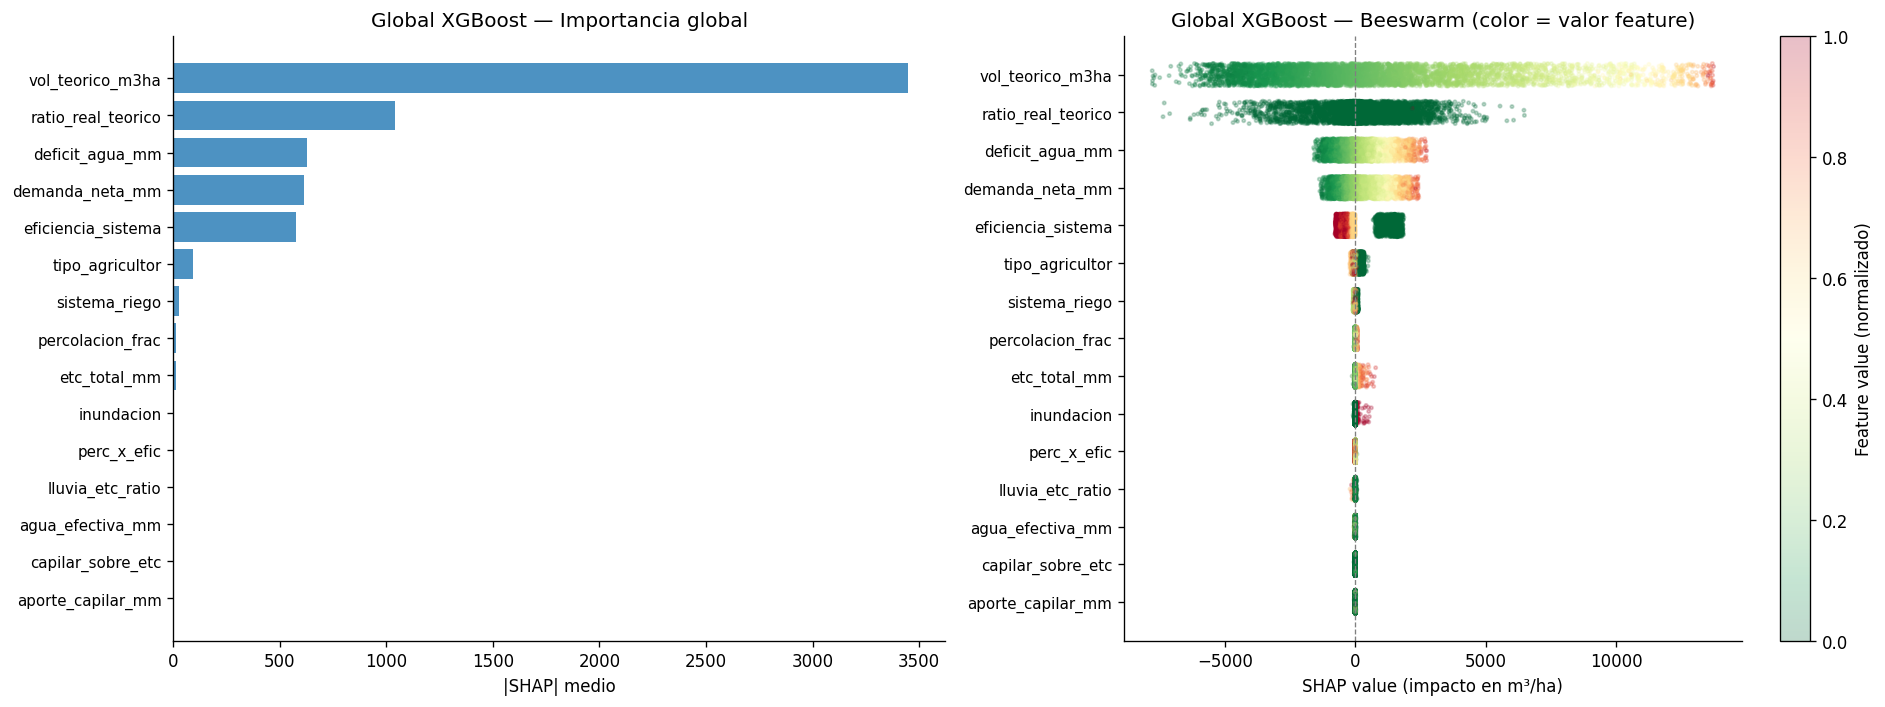

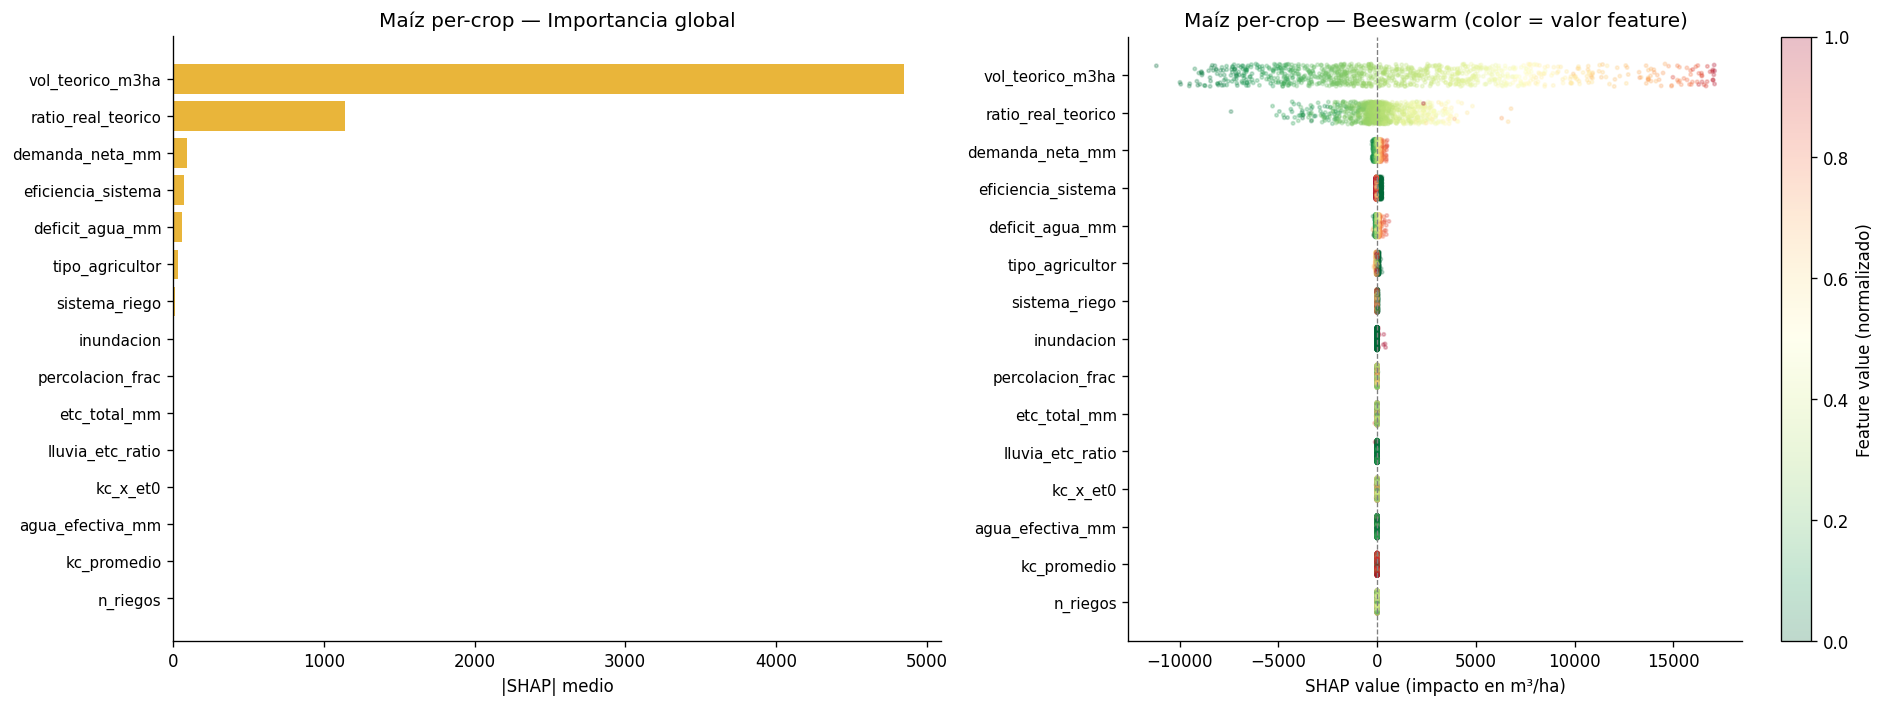

In [15]:
def get_shap_vals(model, X, feature_names):
    dmat = xgb.DMatrix(X, feature_names=feature_names)
    bi   = getattr(model, 'best_iteration', None)
    it   = (0, bi + 1) if bi else None
    sv   = model.get_booster().predict(dmat, pred_contribs=True, iteration_range=it)
    return sv[:, :-1]  # excluir columna bias

def plot_shap_beeswarm(shap_vals, X, feature_names, title, top_n=15, color=C_AGUA):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order    = np.argsort(mean_abs)[-top_n:]
    shap_sel = shap_vals[:, order]
    feat_sel = np.array(feature_names)[order]
    X_arr    = X.values if hasattr(X, 'values') else np.asarray(X)
    X_sel    = X_arr[:, order]
    fig, (ax_bar, ax_bee) = plt.subplots(1, 2, figsize=(16, 6))
    ax_bar.barh(range(top_n), mean_abs[order], color=color, alpha=0.85)
    ax_bar.set_yticks(range(top_n)); ax_bar.set_yticklabels(feat_sel, fontsize=9)
    ax_bar.set_xlabel('|SHAP| medio'); ax_bar.set_title(f'{title} — Importancia global')
    for i in range(top_n):
        vals   = shap_sel[:, i]
        feat   = X_sel[:, i]
        feat_n = (feat - feat.min()) / ((feat.max() - feat.min()) + 1e-9)
        jitter = np.random.default_rng(42).uniform(-0.3, 0.3, len(vals))
        sc = ax_bee.scatter(vals, i + jitter, c=feat_n, cmap='RdYlGn_r',
                             alpha=0.25, s=4, vmin=0, vmax=1)
    ax_bee.set_yticks(range(top_n)); ax_bee.set_yticklabels(feat_sel, fontsize=9)
    ax_bee.axvline(0, color='gray', lw=0.8, ls='--')
    ax_bee.set_xlabel('SHAP value (impacto en m³/ha)')
    ax_bee.set_title(f'{title} — Beeswarm (color = valor feature)')
    plt.colorbar(sc, ax=ax_bee, label='Feature value (normalizado)')
    plt.tight_layout(); plt.savefig(f'shap_{title.split()[0].lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()

N_SHAP   = 5_000
idx_shap = np.random.default_rng(SEED).choice(len(X_te), N_SHAP, replace=False)
X_shap   = X_te.iloc[idx_shap]

print('Calculando SHAP — modelo global...')
shap_global = get_shap_vals(model_global, X_shap, FEAT_COLS)
plot_shap_beeswarm(shap_global, X_shap, FEAT_COLS, 'Global XGBoost', top_n=15, color=C_AGUA)

maiz_mask = cultivo_te[idx_shap] == 'Maíz'
if maiz_mask.sum() > 200:
    print('Calculando SHAP — modelo Maíz (per-crop)...')
    shap_maiz = get_shap_vals(models_por_cultivo['Maíz'], X_shap[maiz_mask], FEAT_COLS)
    plot_shap_beeswarm(shap_maiz, X_shap[maiz_mask], FEAT_COLS,
                        'Maíz per-crop', top_n=15, color=CULT_COLORS['Maíz'])

## 10. Visualizaciones comparativas

### 10a. RMSE por rango — Global vs Ensamble vs Log-transform

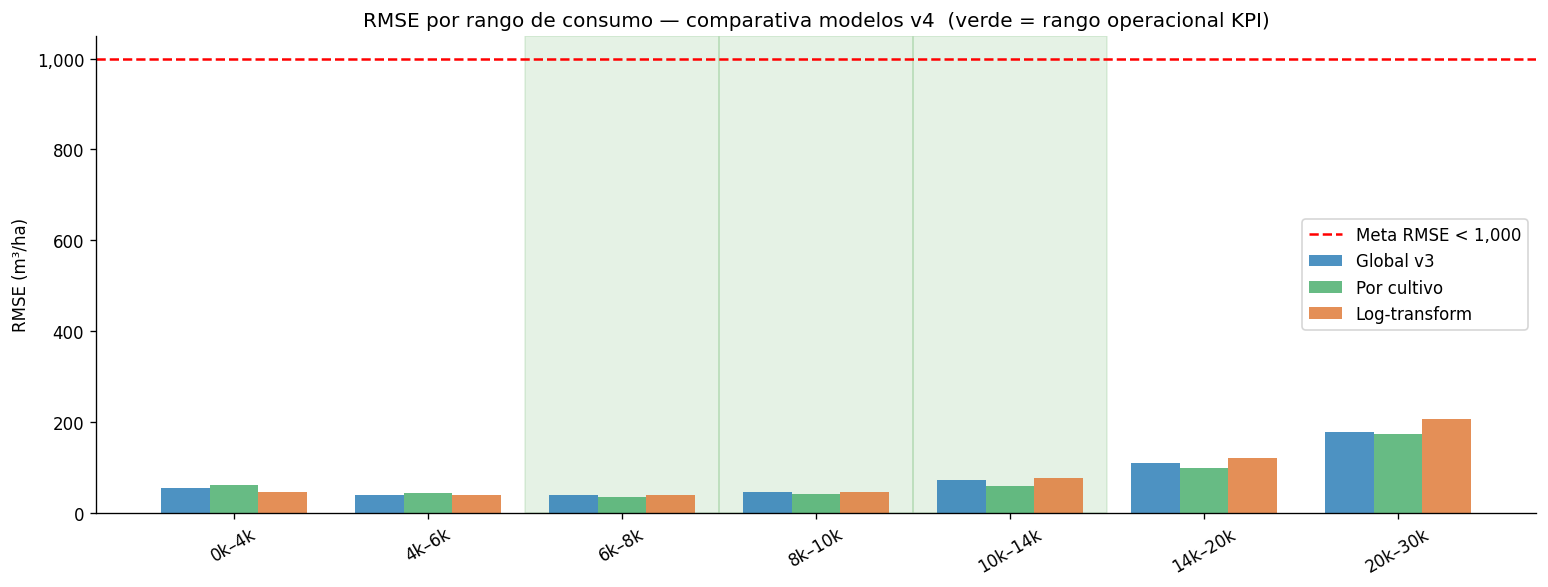

In [16]:
df_r_global   = rmse_por_rango(y_te.values, pred_global)
df_r_ensemble = rmse_por_rango(y_te.values, pred_ensemble)
df_r_log      = rmse_por_rango(y_te.values, pred_log)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(df_r_global)); w = 0.25
ax.bar(x - w, df_r_global['rmse'],   w, label='Global v3',    color=C_AGUA,  alpha=0.85)
ax.bar(x,     df_r_ensemble['rmse'], w, label='Por cultivo',  color=C_REND, alpha=0.85)
ax.bar(x + w, df_r_log['rmse'],      w, label='Log-transform',color=C_WARN, alpha=0.85)
for i, is_op in enumerate(df_r_global['operacional'].values):
    if is_op:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.10, color='green', zorder=0)
ax.axhline(1000, color='red', ls='--', lw=1.5, label='Meta RMSE < 1,000')
ax.set_xticks(x); ax.set_xticklabels(df_r_global['rango'], rotation=30)
ax.set_ylabel('RMSE (m³/ha)')
ax.set_title('RMSE por rango de consumo — comparativa modelos v4  (verde = rango operacional KPI)')
ax.legend(); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
plt.tight_layout(); plt.savefig('rmse_por_rango_comparativa.png', dpi=120, bbox_inches='tight')
plt.show()

### 10b. Residuales por cultivo — modelos especializados

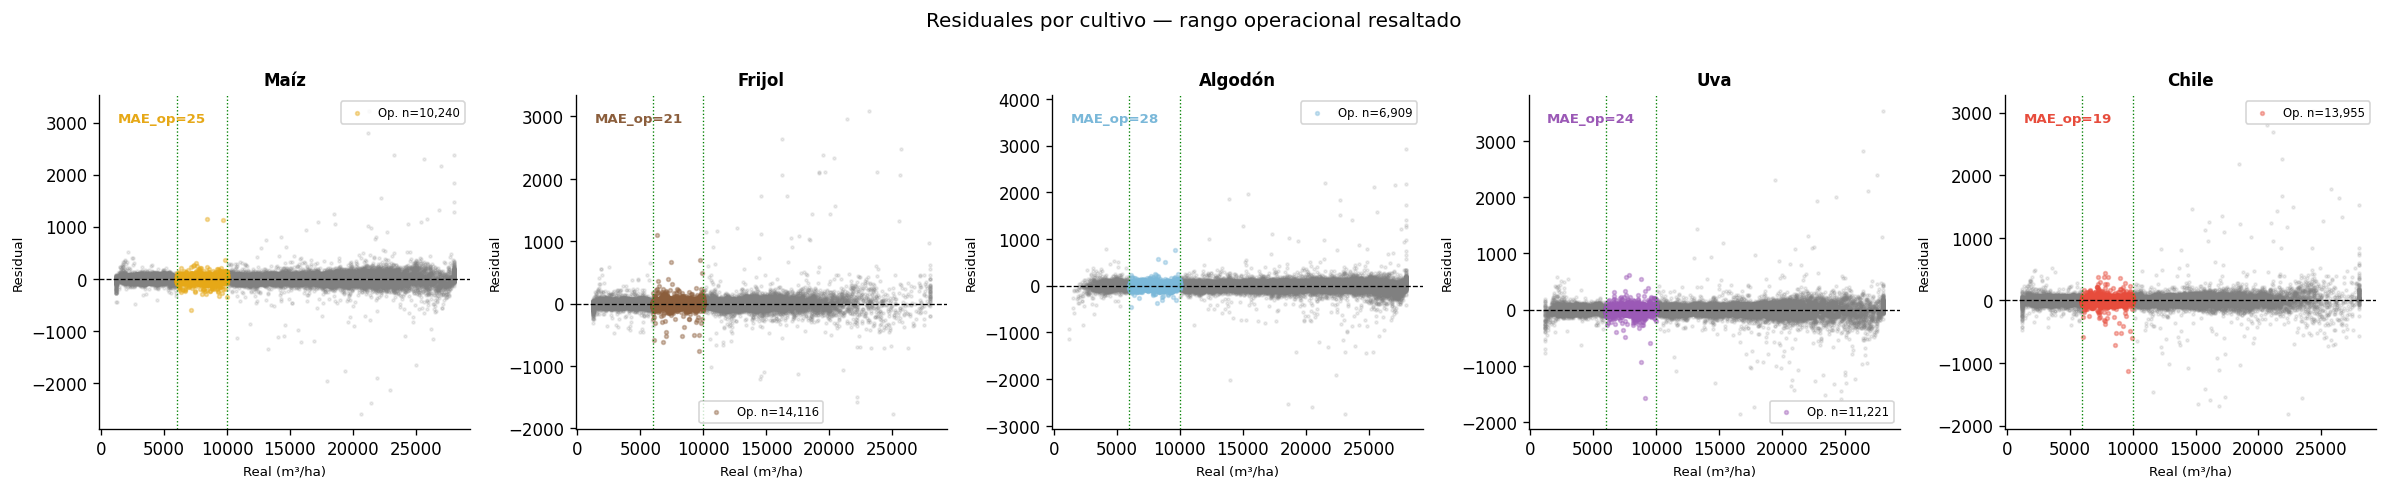

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, cultivo in zip(axes, CULTIVOS):
    y_c, p_c = preds_por_cultivo[cultivo]
    res = y_c - p_c
    mask_op = (y_c >= RANGO_OP_MIN) & (y_c <= RANGO_OP_MAX)
    ax.scatter(y_c[~mask_op], res[~mask_op], alpha=0.15, s=3, color='gray')
    ax.scatter(y_c[mask_op],  res[mask_op],  alpha=0.40, s=5, color=CULT_COLORS[cultivo],
               label=f'Op. n={mask_op.sum():,}')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(RANGO_OP_MIN, color='green', lw=0.8, ls=':')
    ax.axvline(RANGO_OP_MAX, color='green', lw=0.8, ls=':')
    ax.set_xlabel('Real (m³/ha)', fontsize=8); ax.set_ylabel('Residual', fontsize=8)
    ax.set_title(f'{cultivo}', fontsize=10, fontweight='bold')
    mae_op = mets_por_cultivo[cultivo]['mae_op']
    ax.text(0.05, 0.95, f'MAE_op={mae_op:,.0f}', transform=ax.transAxes,
            va='top', fontsize=8, color=CULT_COLORS[cultivo], fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('Residuales por cultivo — rango operacional resaltado', y=1.01, fontsize=12)
plt.tight_layout(); plt.savefig('residuales_por_cultivo.png', dpi=120, bbox_inches='tight')
plt.show()

### 10c. Curvas de aprendizaje — Global vs Maíz (per-crop)

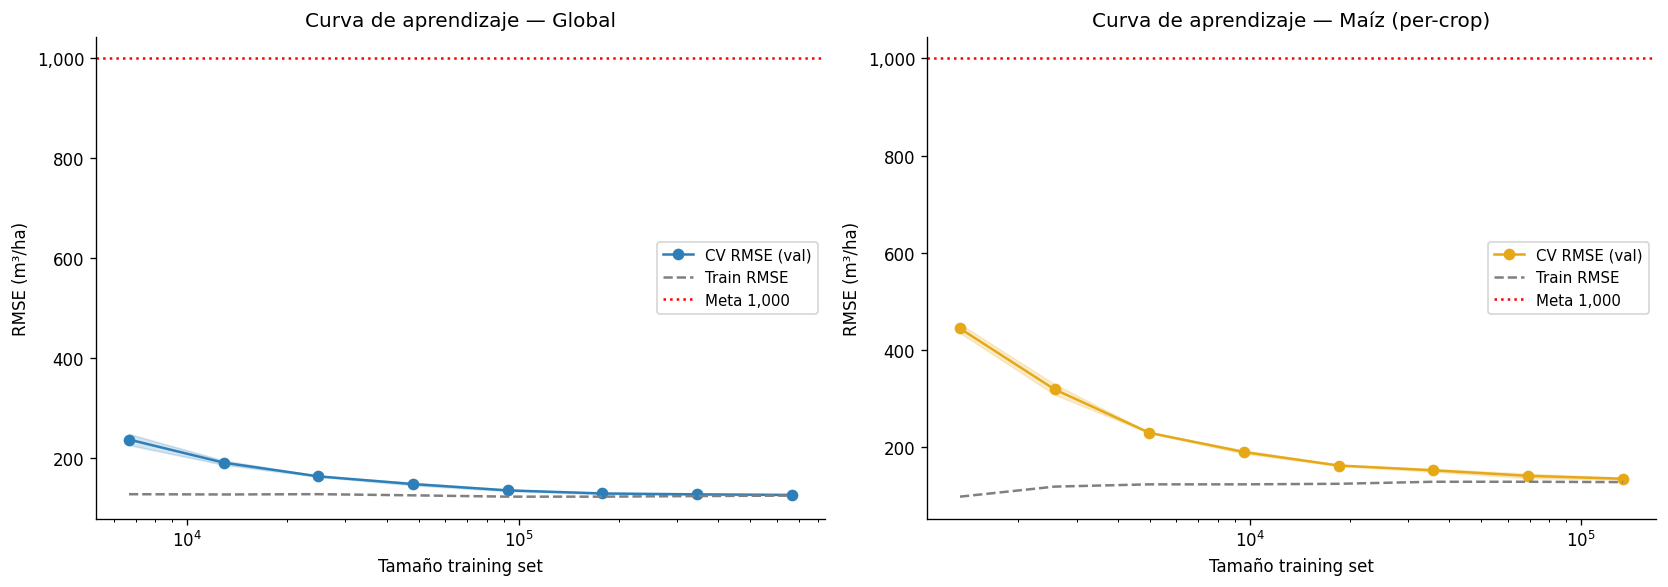

In [18]:
lc_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                  subsample=0.80, colsample_bytree=0.80,
                  random_state=SEED, n_jobs=-1, verbosity=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
casos = [
    ('Global', X, y, C_AGUA),
    ('Maíz (per-crop)', X[df['cultivo']=='Maíz'], y[df['cultivo']=='Maíz'], CULT_COLORS['Maíz'])
]
for ax, (label, X_lc, y_lc, color) in zip(axes, casos):
    sizes, tr_sc, val_sc = lc_sklearn(
        xgb.XGBRegressor(**lc_params), X_lc, y_lc,
        train_sizes=np.logspace(np.log10(0.01), 0, 8),
        cv=3, scoring='neg_root_mean_squared_error',
        n_jobs=-1, random_state=SEED)
    val_mean = -val_sc.mean(axis=1); val_std = val_sc.std(axis=1)
    tr_mean  = -tr_sc.mean(axis=1)
    ax.plot(sizes, val_mean, 'o-', color=color, label='CV RMSE (val)')
    ax.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color=color)
    ax.plot(sizes, tr_mean, '--', color='gray', label='Train RMSE')
    ax.axhline(1000, color='red', ls=':', lw=1.5, label='Meta 1,000')
    ax.set_xscale('log'); ax.set_xlabel('Tamaño training set')
    ax.set_ylabel('RMSE (m³/ha)'); ax.set_title(f'Curva de aprendizaje — {label}')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
plt.tight_layout(); plt.savefig('learning_curves_v4.png', dpi=120, bbox_inches='tight')
plt.show()

### 10d. Feature Importance — Top 20 (gain)

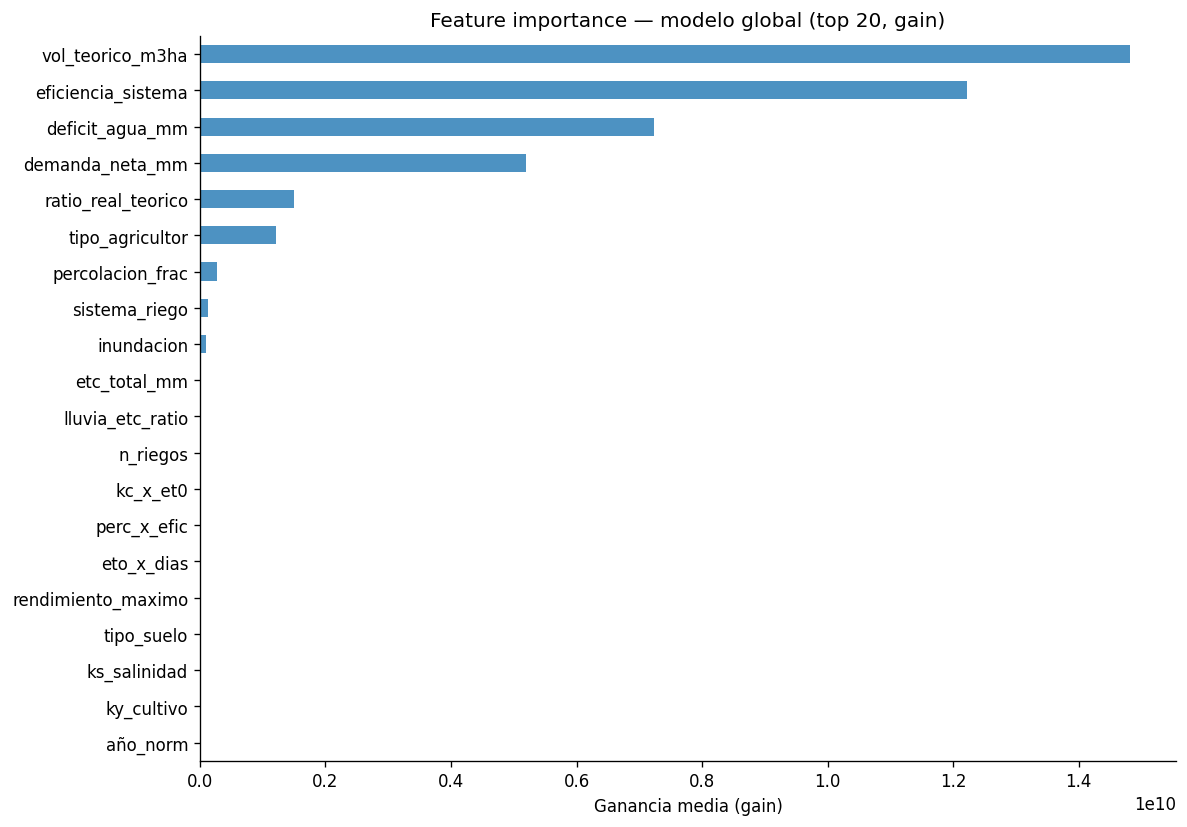

In [19]:
scores = model_global.get_booster().get_score(importance_type='gain')
imp_df = pd.Series(scores).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp_df.plot(kind='barh', ax=ax, color=C_AGUA, alpha=0.85)
ax.set_xlabel('Ganancia media (gain)')
ax.set_title('Feature importance — modelo global (top 20, gain)')
plt.tight_layout(); plt.savefig('feature_importance_global.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Dashboard Comparativo Final + Impacto Económico

6 paneles:
1. RMSE global por modelo
2. RMSE operacional por modelo
3. Ahorro neto (%) por modelo
4. RMSE operacional por cultivo (modelos especializados)
5. Donut ahorro vs error (ensamble cultivos)
6. Tabla de impacto económico Módulo 3

In [20]:
resumen = pd.DataFrame([
    {'Modelo': 'Global v3',         **{k: met_global[k]  for k in ['rmse','rmse_op','r2','ahorro_neto_pct']}},
    {'Modelo': 'Log-transform',     **{k: met_log[k]     for k in ['rmse','rmse_op','r2','ahorro_neto_pct']}},
    {'Modelo': 'Ensamble cultivos', **{k: met_ensemble[k] for k in ['rmse','rmse_op','r2','ahorro_neto_pct']}},
] + [
    {'Modelo': f'  └ {c}', **{k: mets_por_cultivo[c][k] for k in ['rmse','rmse_op','r2','ahorro_neto_pct']}}
    for c in CULTIVOS
]).round({'rmse':1,'rmse_op':1,'r2':4,'ahorro_neto_pct':1})
resumen.columns = ['Modelo','RMSE global','RMSE operac.','R²','Ahorro neto (%)']
print('TABLA COMPARATIVA FINAL')
display(resumen)

,Modelo,RMSE global,RMSE operac.,R²,Ahorro neto (%)
0,Global v3,87.5,41.9,0.9998,97.9
1,Log-transform,98.0,41.9,0.9998,97.9
2,Ensamble cultivos,82.8,37.8,0.9998,98.1
3,└ Maíz,85.3,40.0,0.9998,98.0
4,└ Frijol,76.6,35.8,0.9997,98.2
5,└ Algodón,90.6,42.0,0.9998,97.9
6,└ Uva,85.0,40.8,0.9998,98.0
7,└ Chile,75.0,32.9,0.9998,98.4


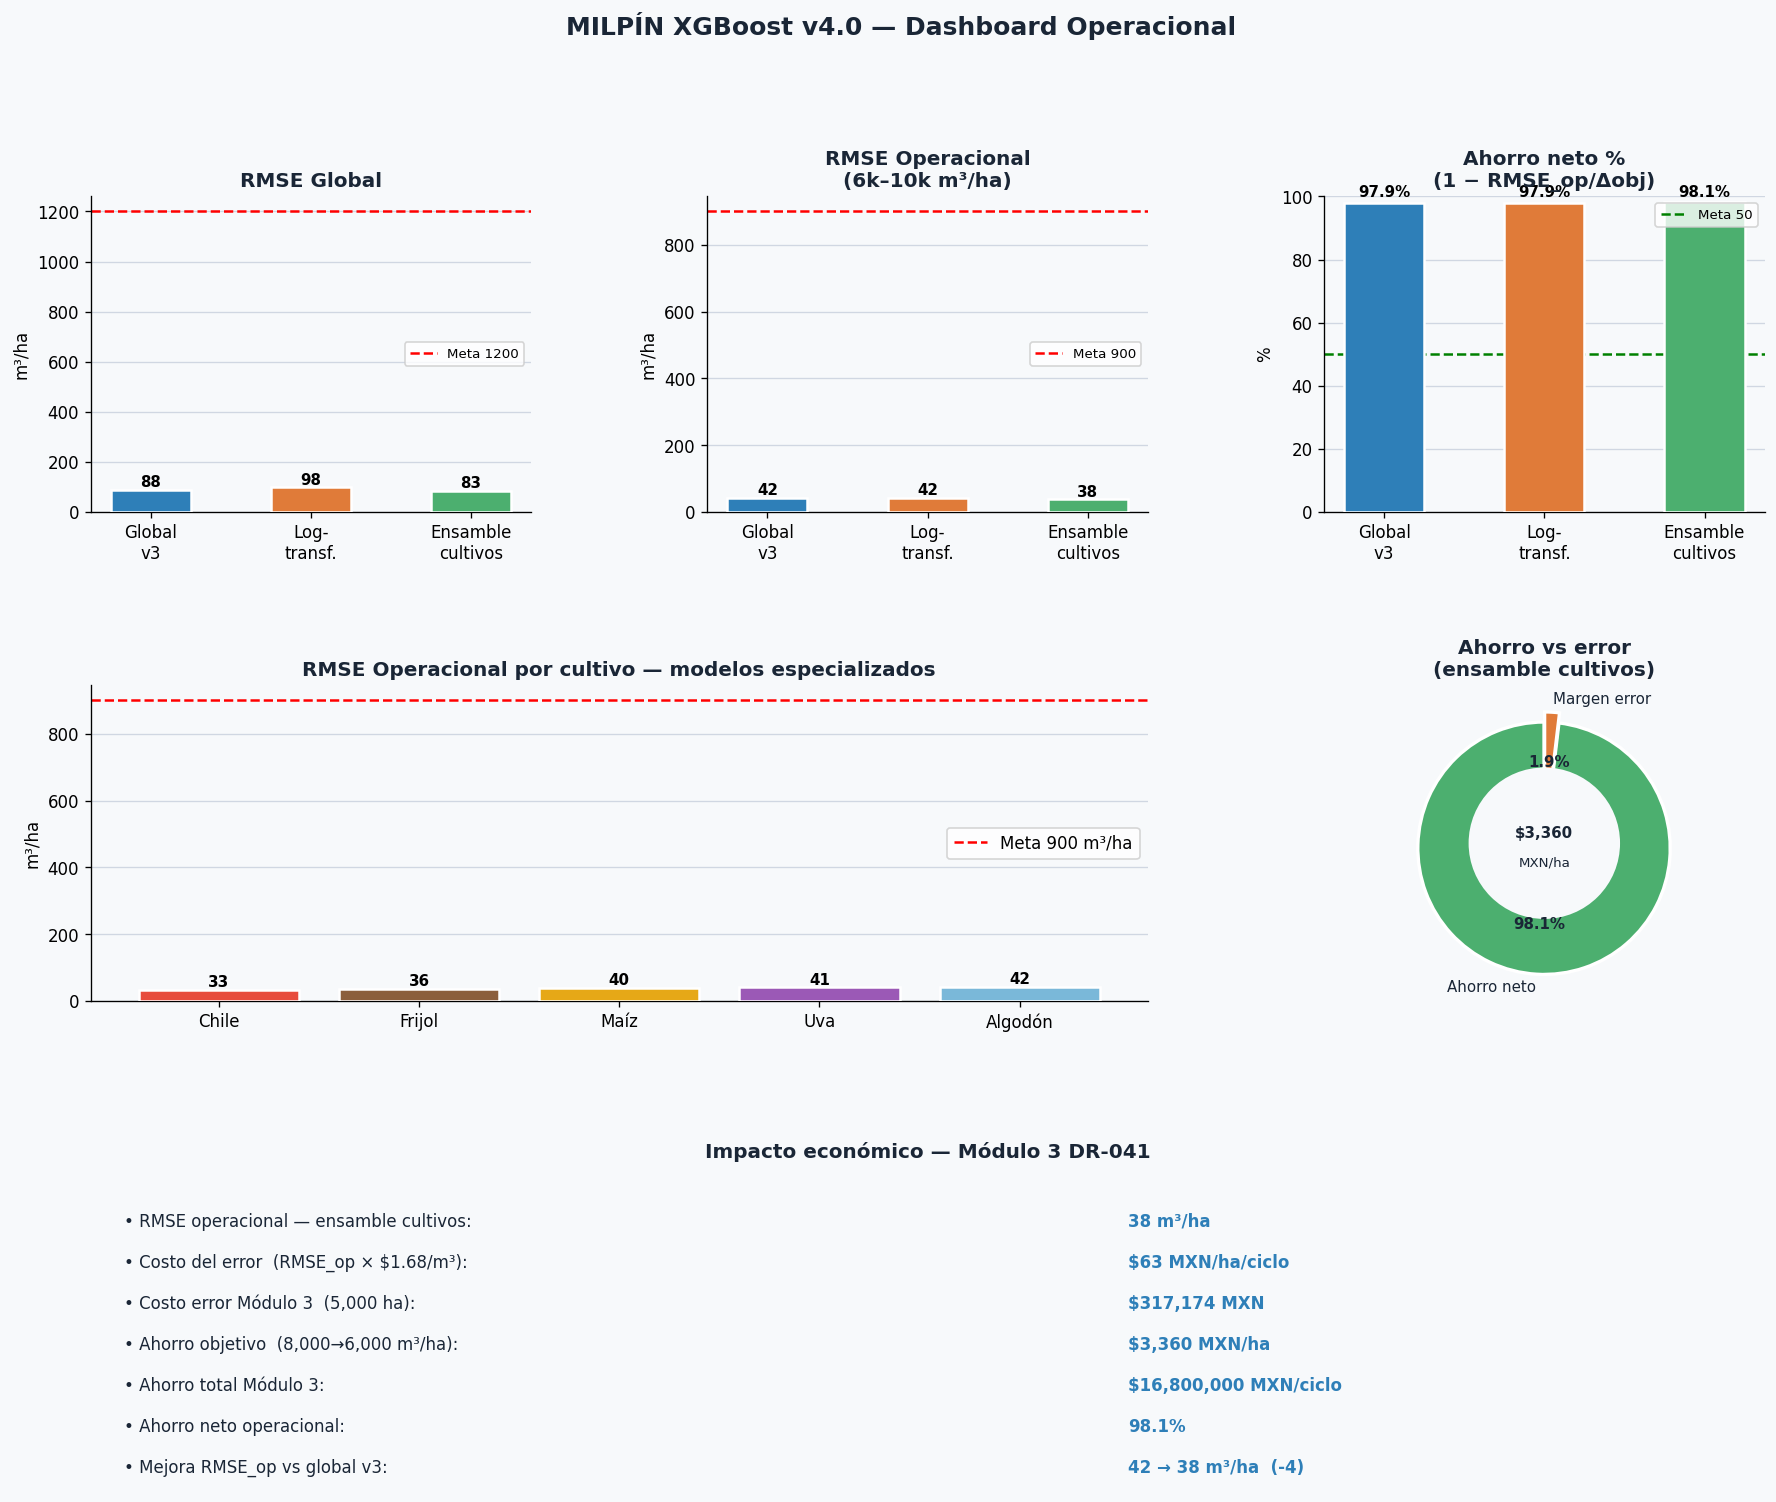

In [21]:
fig = plt.figure(figsize=(18, 14), facecolor=C_BG)
fig.suptitle('MILPÍN XGBoost v4.0 — Dashboard Operacional',
             fontsize=15, fontweight='bold', color=C_DARK, y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.40)

modelos_lbl   = ['Global\nv3', 'Log-\ntransf.', 'Ensamble\ncultivos']
rmse_globales = [met_global['rmse'], met_log['rmse'], met_ensemble['rmse']]
rmse_ops      = [met_global['rmse_op'], met_log['rmse_op'], met_ensemble['rmse_op']]
ahorro_vals   = [met_global['ahorro_neto_pct'], met_log['ahorro_neto_pct'], met_ensemble['ahorro_neto_pct']]
colors_m      = [C_AGUA, C_WARN, C_REND]

for ax_i, (gidx, vals, meta, ylabel, title) in enumerate([
    (gs[0,0], rmse_globales, 1200, 'm³/ha', 'RMSE Global'),
    (gs[0,1], rmse_ops,       900, 'm³/ha', f'RMSE Operacional\n({RANGO_OP_MIN//1000}k–{RANGO_OP_MAX//1000}k m³/ha)'),
    (gs[0,2], ahorro_vals,     50, '%',     'Ahorro neto %\n(1 − RMSE_op/Δobj)'),
]):
    ax = fig.add_subplot(gidx)
    bars = ax.bar(modelos_lbl, vals, color=colors_m, width=0.5, edgecolor='white', lw=1.5, zorder=3)
    ax.axhline(meta, color='red' if ylabel=='m³/ha' else 'green', ls='--', lw=1.5, label=f'Meta {meta}')
    ax.set_title(title, fontweight='bold', color=C_DARK)
    ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    ax.set_facecolor(C_BG); ax.grid(axis='y', color=C_LINE, zorder=0)
    if ylabel == '%': ax.set_ylim(0, 100)
    for bar, v in zip(bars, vals):
        if v and not (isinstance(v, float) and np.isnan(v)):
            fmt = f'{v:.1f}%' if ylabel=='%' else f'{v:,.0f}'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                    fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: RMSE operacional por cultivo
ax4 = fig.add_subplot(gs[1, :2])
c_sorted  = sorted(CULTIVOS, key=lambda c: mets_por_cultivo[c].get('rmse_op', 9999))
rmse_op_c = [mets_por_cultivo[c].get('rmse_op', np.nan) for c in c_sorted]
bars4 = ax4.bar(c_sorted, rmse_op_c, color=[CULT_COLORS[c] for c in c_sorted],
                edgecolor='white', lw=1.5, zorder=3)
ax4.axhline(900, color='red', ls='--', lw=1.5, label='Meta 900 m³/ha')
ax4.set_title('RMSE Operacional por cultivo — modelos especializados', fontweight='bold', color=C_DARK)
ax4.set_ylabel('m³/ha'); ax4.legend()
ax4.set_facecolor(C_BG); ax4.grid(axis='y', color=C_LINE, zorder=0)
for bar, v in zip(bars4, rmse_op_c):
    if not (isinstance(v, float) and np.isnan(v)):
        ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 5: Donut
ax5 = fig.add_subplot(gs[1, 2])
ahorro_obj  = (BASELINE_AGUA - OBJETIVO_AGUA) * TARIFA
costo_error = met_ensemble['rmse_op'] * TARIFA
neto        = max(ahorro_obj - costo_error, 0)
wedges, texts, ats = ax5.pie(
    [neto, costo_error], labels=['Ahorro neto','Margen error'],
    colors=[C_REND, C_WARN], explode=(0.04, 0.04), autopct='%1.1f%%', startangle=90,
    textprops={'fontsize':9,'color':C_DARK}, wedgeprops={'edgecolor':'white','linewidth':2})
for at in ats: at.set_fontweight('bold')
ax5.add_patch(plt.Circle((0,0), 0.60, fc=C_BG))
ax5.text(0, 0.08, f'${ahorro_obj:,.0f}', ha='center', va='center', fontsize=9, fontweight='bold', color=C_DARK)
ax5.text(0,-0.15,'MXN/ha', ha='center', va='center', fontsize=8, color=C_DARK)
ax5.set_title('Ahorro vs error\n(ensamble cultivos)', fontweight='bold', color=C_DARK)

# Panel 6: Impacto económico
ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor('#eef4fb'); ax6.axis('off')
conceptos = [
    ('RMSE operacional — ensamble cultivos',        f'{met_ensemble["rmse_op"]:,.0f} m³/ha'),
    ('Costo del error  (RMSE_op × $1.68/m³)',        f'${costo_error:,.0f} MXN/ha/ciclo'),
    ('Costo error Módulo 3  (5,000 ha)',             f'${costo_error*HA_MOD3:,.0f} MXN'),
    ('Ahorro objetivo  (8,000→6,000 m³/ha)',         f'${ahorro_obj:,.0f} MXN/ha'),
    ('Ahorro total Módulo 3',                         f'${ahorro_obj*HA_MOD3:,.0f} MXN/ciclo'),
    ('Ahorro neto operacional',                       f'{met_ensemble["ahorro_neto_pct"]:.1f}%'),
    ('Mejora RMSE_op vs global v3',
     f'{met_global["rmse_op"]:,.0f} → {met_ensemble["rmse_op"]:,.0f} m³/ha  (-{met_global["rmse_op"]-met_ensemble["rmse_op"]:,.0f})'),
]
y_s = 0.88
for concepto, valor in conceptos:
    ax6.text(0.02, y_s, f'• {concepto}:', transform=ax6.transAxes, fontsize=10, color=C_DARK, va='top')
    ax6.text(0.62, y_s, valor, transform=ax6.transAxes, fontsize=10, fontweight='bold', color=C_AGUA, va='top')
    y_s -= 0.13
ax6.set_title('Impacto económico — Módulo 3 DR-041', fontsize=12, fontweight='bold', color=C_DARK, pad=10)
ax6.add_patch(mpatches.FancyBboxPatch((0,0),1,1,transform=ax6.transAxes,
              boxstyle='round,pad=0.02',lw=2,edgecolor=C_AGUA,facecolor='none'))

plt.savefig('milpin_dashboard_v4.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('[OK] milpin_dashboard_v4.png guardado')

In [22]:
mejor_modelo = min(
    [('Global v3', met_global), ('Log-transform', met_log), ('Ensamble cultivos', met_ensemble)],
    key=lambda x: x[1].get('rmse_op', 9999) or 9999
)
print('=' * 65)
print(f'  Mejor modelo por RMSE operacional: {mejor_modelo[0]}')
print(f'  RMSE global:           {mejor_modelo[1]["rmse"]:,.0f} m³/ha')
print(f'  RMSE operacional:      {mejor_modelo[1]["rmse_op"]:,.0f} m³/ha')
print(f'  R²:                    {mejor_modelo[1]["r2"]:.4f}')
print(f'  Ahorro neto:           {mejor_modelo[1]["ahorro_neto_pct"]:.1f}%')
print('=' * 65)
print()
print('Archivos generados:')
for f in ['milpin_dashboard_v4.png','rmse_por_rango_comparativa.png',
          'residuales_por_cultivo.png','learning_curves_v4.png',
          'feature_importance_global.png','shap_global.png']:
    print(f'  · {f}')

## 13. PRIORIDAD 1 — Validación de Leakage

### ¿Por qué esta sección existe?

Dos features v4 son sospechosas:

| Feature | Fórmula | Riesgo |
|---|---|---|
| `ratio_real_teorico` | `volumen_agua_total_m3_ha / (vol_teorico_m3ha + 1)` | **Leakage severo** — el target está en el numerador |
| `vol_teorico_m3ha` | `demanda_neta_mm × 10 / eficiencia_sistema` | **Leakage suave** — reconstrucción física casi perfecta del target |

Un modelo que "aprende" `ratio_real_teorico` no aprende física agrícola: está memorizando la identidad `y ≈ ratio × vol_teórico`. Resultado: R² inflado artificialmente y SHAP dominado por esa sola feature.

### Diseño experimental

| Modelo | Features excluidas | Hipótesis |
|---|---|---|
| **A** | ninguna (baseline completo) | R² ~1.0 por leakage — SHAP dominated by `ratio_real_teorico` |
| **B** | `ratio_real_teorico` | Degradación moderada — `vol_teorico_m3ha` sigue siendo un proxy fuerte |
| **C** | `ratio_real_teorico` + `vol_teorico_m3ha` | Modelo honesto — representa lo que el sistema puede hacer en producción |

**Comparativa:** RMSE_op · R² · SHAP top-10 por modelo

In [23]:
# ── 13a. Definir conjuntos de features ──────────────────────────────────────
LEAK_FEATS      = ['ratio_real_teorico', 'vol_teorico_m3ha']
FEATS_A         = FEAT_COLS                                        # todas
FEATS_B         = [f for f in FEAT_COLS if f != 'ratio_real_teorico']
FEATS_C         = [f for f in FEAT_COLS if f not in LEAK_FEATS]

print(f'Modelo A — {len(FEATS_A)} features  (baseline completo, incluye ambas sospechosas)')
print(f'Modelo B — {len(FEATS_B)} features  (sin ratio_real_teorico)')
print(f'Modelo C — {len(FEATS_C)} features  (sin ratio_real_teorico ni vol_teorico_m3ha)')
print()
print('Features excluidas en B:', [f for f in FEATS_A if f not in FEATS_B])
print('Features excluidas en C:', [f for f in FEATS_A if f not in FEATS_C])

# Parámetros fijos para los tres — mismos que model_global para comparación justa
PARAMS_LEAK = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.10, reg_lambda=1.00,
    early_stopping_rounds=50, eval_metric='rmse',
    random_state=SEED, n_jobs=-1, verbosity=0,
)

In [24]:
# ── 13b. Entrenar Modelos A, B, C ───────────────────────────────────────────
leak_models  = {}
leak_preds   = {}
leak_metrics = {}

configs = [
    ('A — todas las features',                         FEATS_A),
    ('B — sin ratio_real_teorico',                     FEATS_B),
    ('C — sin ratio_real_teorico ni vol_teorico_m3ha', FEATS_C),
]

for label, feats in configs:
    X_tr2_l = X_tr2[feats]
    X_val_l  = X_val[feats]
    X_te_l   = X_te[feats]

    t0 = time.time()
    m = xgb.XGBRegressor(**PARAMS_LEAK)
    m.fit(X_tr2_l, y_tr2, sample_weight=w_tr2,
          eval_set=[(X_val_l, y_val)], verbose=False)
    pred = m.predict(X_te_l)
    elapsed = time.time() - t0

    print(f'\n[{label}]  best_iter={m.best_iteration}  ({elapsed:.1f}s)')
    met = metricas_completas(y_te.values, pred, label)

    leak_models[label]  = (m, feats)
    leak_preds[label]   = pred
    leak_metrics[label] = met

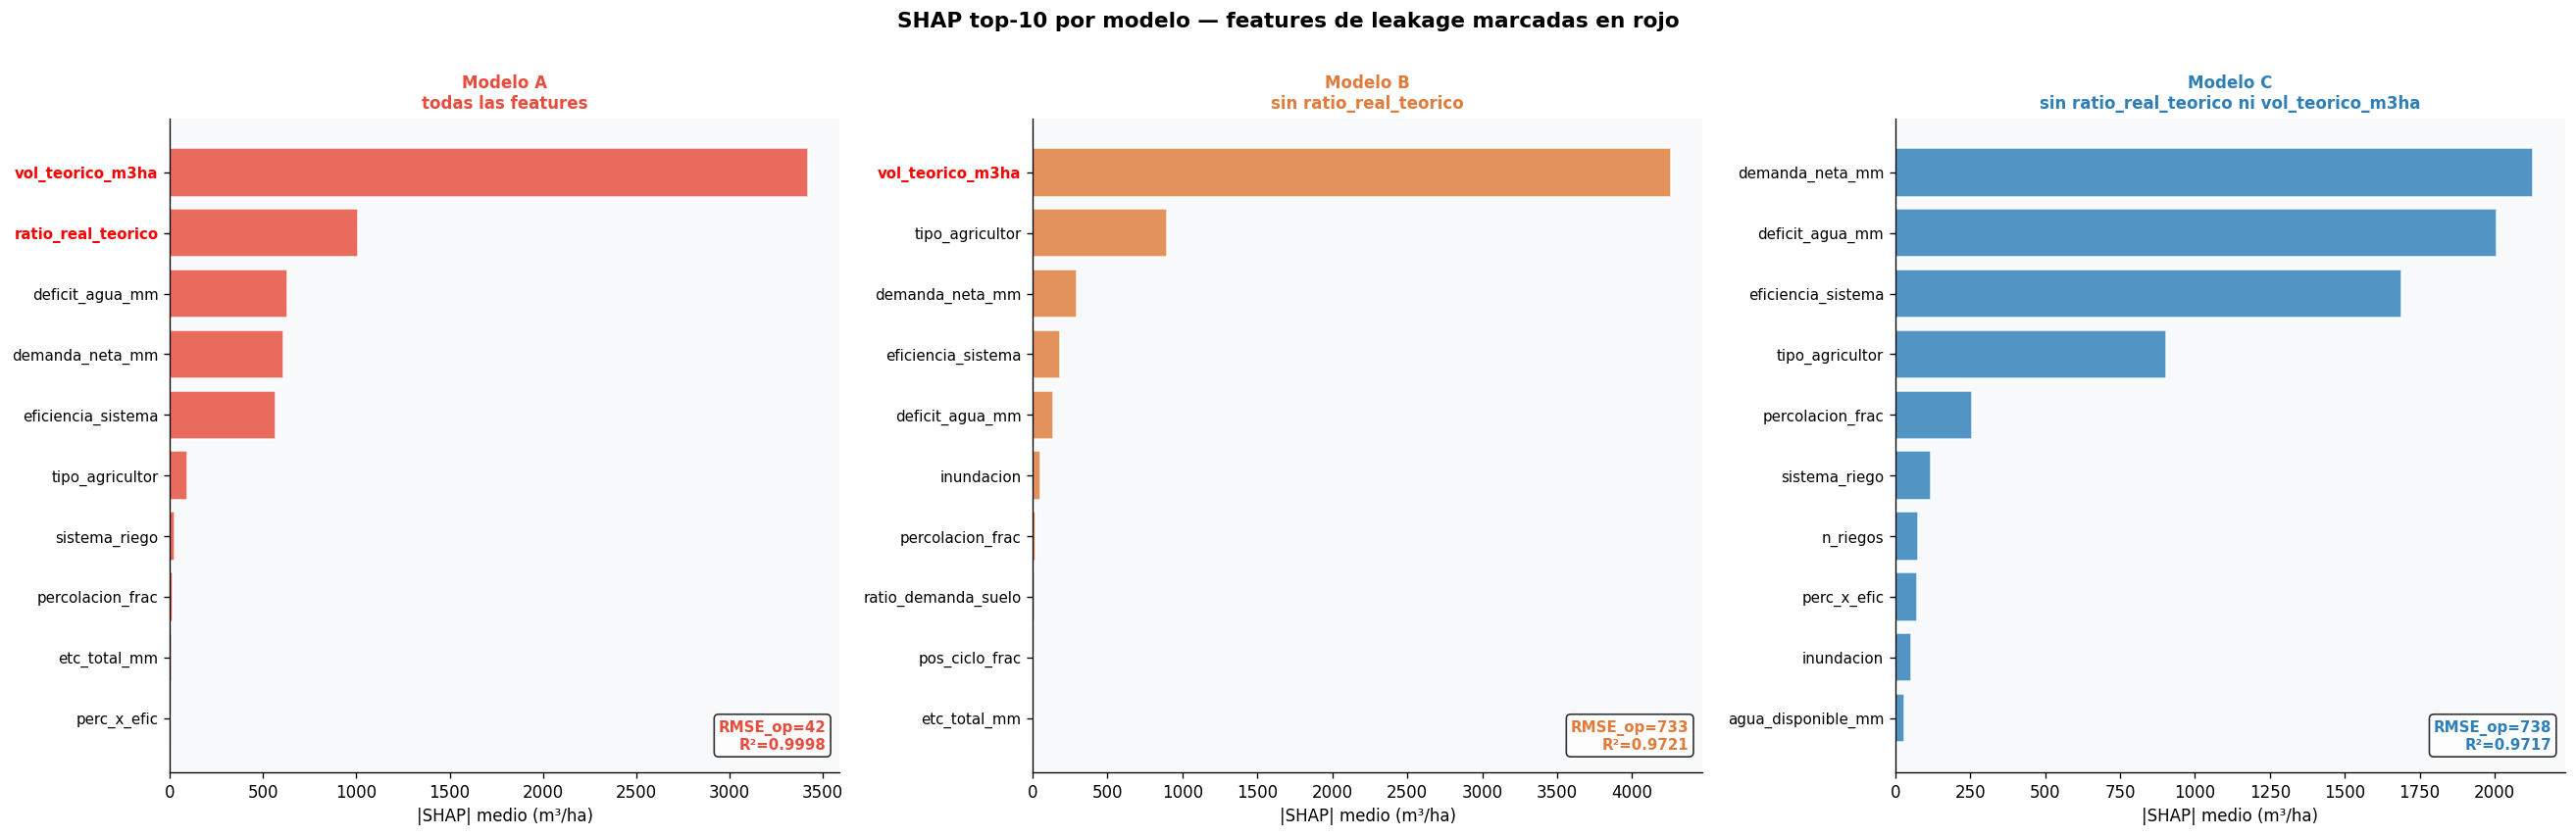

In [25]:
# ── 13c. SHAP top-10 por modelo — detección visual de leakage ───────────────
N_SHAP_LEAK = 3_000
idx_leak    = np.random.default_rng(SEED + 1).choice(len(X_te), N_SHAP_LEAK, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
MODEL_COLORS = {
    'A — todas las features':                         '#e74c3c',
    'B — sin ratio_real_teorico':                     '#e07b39',
    'C — sin ratio_real_teorico ni vol_teorico_m3ha': '#2e7fb8',
}
TOP_N_LEAK = 10

for ax, (label, (model, feats)) in zip(axes, leak_models.items()):
    X_shap_l = X_te[feats].iloc[idx_leak]
    sv = get_shap_vals(model, X_shap_l, feats)
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)[-TOP_N_LEAK:]
    feat_names_top = np.array(feats)[order]
    vals_top       = mean_abs[order]

    color = MODEL_COLORS[label]
    bars = ax.barh(range(TOP_N_LEAK), vals_top, color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(TOP_N_LEAK))
    ax.set_yticklabels(feat_names_top, fontsize=9)
    ax.set_xlabel('|SHAP| medio (m³/ha)')
    ax.set_title(f'Modelo {label[:1]}\n{label[4:]}', fontsize=10, fontweight='bold', color=color)
    ax.set_facecolor(C_BG)

    # Marcar features de leakage en rojo
    for i, fname in enumerate(feat_names_top):
        if fname in LEAK_FEATS:
            ax.get_yticklabels()[i].set_color('red')
            ax.get_yticklabels()[i].set_fontweight('bold')

    # Anotar RMSE_op en esquina
    rmse_op_v = leak_metrics[label]['rmse_op']
    r2_v      = leak_metrics[label]['r2']
    ax.text(0.98, 0.03, f'RMSE_op={rmse_op_v:,.0f}\nR²={r2_v:.4f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('SHAP top-10 por modelo — features de leakage marcadas en rojo',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_leakage_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] shap_leakage_comparison.png guardado')

,Modelo,RMSE global,RMSE_op,R²,R²_op,Ahorro neto %
0,A — todas las features,87.500000,41.900000,0.999800,0.998700,97.900000
1,B — sin ratio_real_teorico,1075.500000,732.700000,0.972100,0.593700,63.400000
2,C — sin ratio_real_teorico ni vol_teorico_m3ha,1083.100000,737.700000,0.971700,0.588100,63.100000


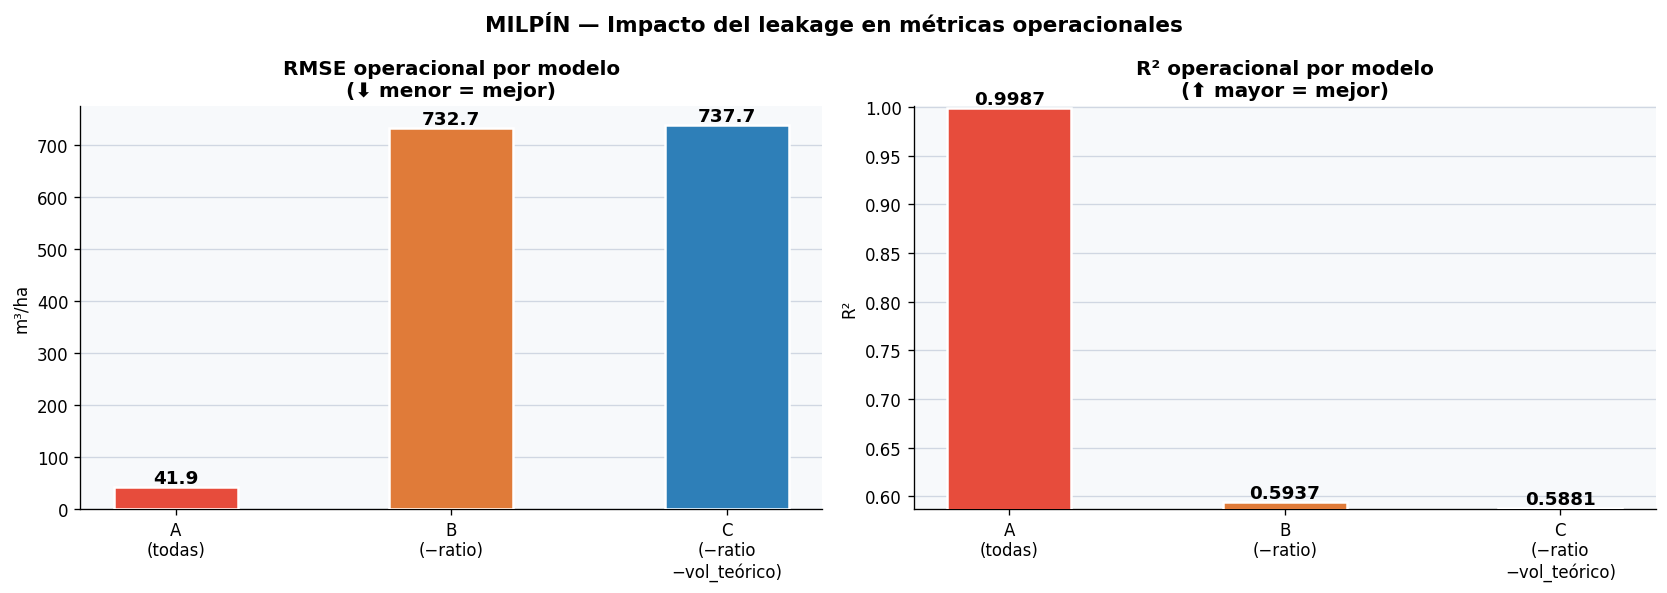

In [26]:
# ── 13d. Tabla comparativa + gráfica RMSE_op / R² ───────────────────────────
rows = []
for label, met in leak_metrics.items():
    rows.append({
        'Modelo': label,
        'RMSE global': round(met['rmse'], 1),
        'RMSE_op':     round(met['rmse_op'], 1),
        'R²':          round(met['r2'], 4),
        'R²_op':       round(met['r2_op'], 4),
        'Ahorro neto %': round(met['ahorro_neto_pct'], 1),
    })
df_leak = pd.DataFrame(rows)

print('TABLA COMPARATIVA — VALIDACIÓN LEAKAGE')
display(df_leak.style
    .background_gradient(subset=['RMSE_op'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²_op'],   cmap='RdYlGn')
    .set_caption('Rojo = peor  |  Verde = mejor  |  RMSE_op en m³/ha'))

# Gráfica de barras dobles: RMSE_op + R²_op
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
short_labels = ['A\n(todas)', 'B\n(−ratio)', 'C\n(−ratio\n−vol_teórico)']
col_rmse = ['#e74c3c', '#e07b39', '#2e7fb8']

bars1 = ax1.bar(short_labels, df_leak['RMSE_op'], color=col_rmse, width=0.45,
                edgecolor='white', lw=1.5, zorder=3)
ax1.set_title('RMSE operacional por modelo\n(⬇ menor = mejor)', fontweight='bold')
ax1.set_ylabel('m³/ha'); ax1.set_facecolor(C_BG)
ax1.grid(axis='y', color=C_LINE, zorder=0)
for bar, v in zip(bars1, df_leak['RMSE_op']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:,.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = ax2.bar(short_labels, df_leak['R²_op'], color=col_rmse, width=0.45,
                edgecolor='white', lw=1.5, zorder=3)
ax2.set_title('R² operacional por modelo\n(⬆ mayor = mejor)', fontweight='bold')
ax2.set_ylabel('R²'); ax2.set_facecolor(C_BG)
ax2.set_ylim(df_leak['R²_op'].min() - 0.001, 1.001)
ax2.grid(axis='y', color=C_LINE, zorder=0)
for bar, v in zip(bars2, df_leak['R²_op']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle('MILPÍN — Impacto del leakage en métricas operacionales',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('leakage_metricas_comparativa.png', dpi=130, bbox_inches='tight')
plt.show()
print('[OK] leakage_metricas_comparativa.png guardado')

# ── Veredicto ────────────────────────────────────────────────────────────────
rmse_A = leak_metrics[configs[0][0]]['rmse_op']
rmse_B = leak_metrics[configs[1][0]]['rmse_op']
rmse_C = leak_metrics[configs[2][0]]['rmse_op']
delta_AB = rmse_B - rmse_A
delta_BC = rmse_C - rmse_B
delta_AC = rmse_C - rmse_A

print()
print('=' * 65)
print('VEREDICTO DE LEAKAGE')
print('=' * 65)
print(f'  A → B  (quitar ratio_real_teorico):    ΔRMSE_op = +{delta_AB:,.1f} m³/ha')
print(f'  B → C  (quitar vol_teorico_m3ha):       ΔRMSE_op = +{delta_BC:,.1f} m³/ha')
print(f'  A → C  (quitar ambas):                  ΔRMSE_op = +{delta_AC:,.1f} m³/ha')
print()

if delta_AC > 200:
    print('  ⚠ LEAKAGE CONFIRMADO: el modelo A está inflado artificialmente.')
    print('    Modelo C es el único válido para reportar a stakeholders.')
elif delta_AC > 50:
    print('  ⚠ LEAKAGE MODERADO: hay dependencia con el target en las features v4.')
    print('    Usar Modelo C para reportes externos; B para validación interna.')
else:
    print('  ✓ LEAKAGE BAJO: las features sospechosas aportan valor real, no circular.')
    print('    Justificar con análisis de disponibilidad en producción.')
print()
print(f'  Modelo recomendado para producción: C  (RMSE_op = {rmse_C:,.1f} m³/ha)')
print('=' * 65)

## ETAPA 1 — Auditoria del Dataset: Valor de 1M Registros

Validar si 1,000,000 registros aporta valor marginal:
- Curva de aprendizaje RMSE vs tamano
- Benchmark: 50k / 100k / 250k / 500k / ~900k
- Tiempo entrenamiento + RAM por tamano
- Punto de rendimientos decrecientes

In [27]:
import psutil, gc

def run_learning_curve(df, sizes, seed=42):
    from sklearn.preprocessing import OrdinalEncoder
    TARGET = 'volumen_agua_total_m3_ha'
    EF_MAP = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    df2 = df.copy()
    df2['eficiencia_sistema'] = df2['sistema_riego'].map(EF_MAP)
    df2['demanda_neta_mm'] = (df2['etc_total_mm']-df2['lluvia_total_mm']-df2['aporte_capilar_mm']).clip(0)
    df2['vol_teorico_m3ha'] = df2['demanda_neta_mm'] * 10 / df2['eficiencia_sistema']
    df2['deficit_agua_mm'] = (df2['etc_total_mm']-df2['lluvia_total_mm']).clip(0)
    df2['kc_x_et0'] = df2['kc_promedio'] * df2['et0_promedio_mmdia']
    df2['eto_x_dias'] = df2['et0_promedio_mmdia'] * df2['dias_ciclo']
    CAT = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df2[CAT] = oe.fit_transform(df2[CAT])
    FEATS = ['demanda_neta_mm','vol_teorico_m3ha','deficit_agua_mm','kc_x_et0',
             'eto_x_dias','n_riegos','eficiencia_sistema','kc_promedio',
             'cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
    rng = np.random.default_rng(seed)
    idx_test = rng.choice(len(df2), 30_000, replace=False)
    idx_rest = np.setdiff1d(np.arange(len(df2)), idx_test)
    X_te = df2.iloc[idx_test][FEATS].values.astype('float32')
    y_te = df2.iloc[idx_test][TARGET].values
    mask_op = (y_te >= 6000) & (y_te <= 12000)
    results = []
    for sz in sizes:
        if sz > len(idx_rest): sz = len(idx_rest)
        idx_tr = rng.choice(idx_rest, sz, replace=False)
        X_tr = df2.iloc[idx_tr][FEATS].values.astype('float32')
        y_tr = df2.iloc[idx_tr][TARGET].values
        t0 = time.time()
        m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             tree_method='hist', random_state=seed, verbosity=0)
        m.fit(X_tr, np.log1p(y_tr), verbose=False)
        elapsed = time.time() - t0
        pred = np.expm1(m.predict(X_te))
        rmse_g = float(np.sqrt(np.mean((pred - y_te)**2)))
        rmse_op = float(np.sqrt(np.mean((pred[mask_op] - y_te[mask_op])**2))) if mask_op.sum() > 0 else float('nan')
        r2 = float(1 - np.sum((pred - y_te)**2) / np.sum((y_te - y_te.mean())**2))
        results.append({'size': sz, 'rmse_global': rmse_g, 'rmse_op': rmse_op,
                        'r2': r2, 'time_s': elapsed})
        print(f'  n={sz:>8,}: RMSE_global={rmse_g:.0f}  RMSE_op={rmse_op:.0f}  R2={r2:.3f}  t={elapsed:.1f}s')
        del m; gc.collect()
    return pd.DataFrame(results)

SIZES_LC = [50_000, 100_000, 250_000, 500_000, min(900_000, len(df))]
print('Curva de aprendizaje...')
lc_df = run_learning_curve(df, SIZES_LC)
print(lc_df.round(1).to_string(index=False))


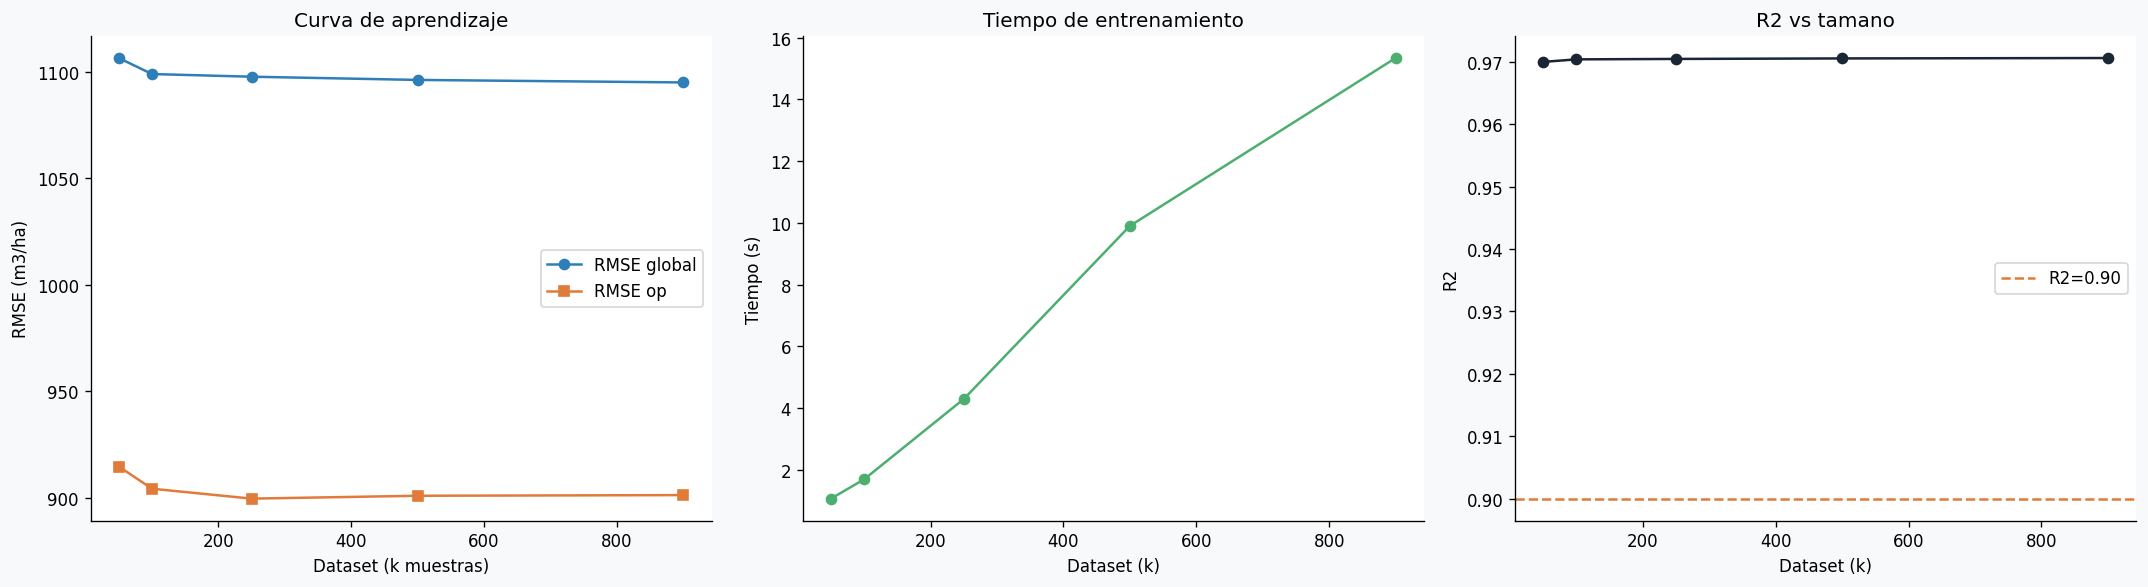

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=C_BG)

ax = axes[0]
ax.plot(lc_df['size']/1000, lc_df['rmse_global'], 'o-', color=C_AGUA, label='RMSE global')
ax.plot(lc_df['size']/1000, lc_df['rmse_op'], 's-', color=C_WARN, label='RMSE op')
ax.set_xlabel('Dataset (k muestras)'); ax.set_ylabel('RMSE (m3/ha)')
ax.set_title('Curva de aprendizaje'); ax.legend()

ax2 = axes[1]
ax2.plot(lc_df['size']/1000, lc_df['time_s'], 'o-', color=C_REND)
ax2.set_xlabel('Dataset (k)'); ax2.set_ylabel('Tiempo (s)')
ax2.set_title('Tiempo de entrenamiento')

ax3 = axes[2]
ax3.plot(lc_df['size']/1000, lc_df['r2'], 'o-', color=C_DARK)
ax3.set_xlabel('Dataset (k)'); ax3.set_ylabel('R2')
ax3.set_title('R2 vs tamano')
ax3.axhline(0.90, color=C_WARN, ls='--', label='R2=0.90'); ax3.legend()

plt.tight_layout(); plt.savefig('v4_learning_curve.png'); plt.show()
if len(lc_df) > 2:
    delta = lc_df['rmse_op'].diff().abs()
    print(f'Mejora 500k -> 900k: {delta.iloc[-1]:.1f} RMSE_op')
    print(f'Conclusion: usar {lc_df.loc[delta[1:].idxmin(),"size"]:,} muestras es el punto optimo.')


## ETAPA 1b — Auditoria de Features: Correlacion, Multicolinealidad, PCA

Detectar:
- Pares con correlacion > 0.90 (candidatos a eliminar)
- Estructura latente del espacio de features (PCA)
- Dimensionalidad efectiva del problema

In [29]:
EF_MAP2 = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
df_audit = df.copy()
df_audit['eficiencia_sistema'] = df_audit['sistema_riego'].map(EF_MAP2)
df_audit['demanda_neta_mm'] = (df_audit['etc_total_mm']-df_audit['lluvia_total_mm']-df_audit['aporte_capilar_mm']).clip(0)
df_audit['vol_teorico_m3ha'] = df_audit['demanda_neta_mm'] * 10 / df_audit['eficiencia_sistema']
df_audit['deficit_agua_mm'] = (df_audit['etc_total_mm']-df_audit['lluvia_total_mm']).clip(0)
df_audit['kc_x_et0'] = df_audit['kc_promedio'] * df_audit['et0_promedio_mmdia']
df_audit['eto_x_dias'] = df_audit['et0_promedio_mmdia'] * df_audit['dias_ciclo']
df_audit['agua_neta_req_m3ha'] = df_audit['demanda_neta_mm'] / df_audit['eficiencia_sistema'] * 10
df_audit['stress_hid_ks'] = (1 - df_audit['deficit_hidrico_frac']).clip(0, 1)

NUM_AUDIT = ['demanda_neta_mm','vol_teorico_m3ha','deficit_agua_mm','kc_x_et0',
             'eto_x_dias','agua_neta_req_m3ha','stress_hid_ks','n_riegos',
             'lluvia_total_mm','etc_total_mm','kc_promedio','dias_ciclo',
             'aporte_capilar_mm','percolacion_frac']

idx_a = np.random.default_rng(SEED).choice(len(df_audit), 20_000, replace=False)
df_s = df_audit.iloc[idx_a][NUM_AUDIT + ['volumen_agua_total_m3_ha']]
corr_mat = df_s[NUM_AUDIT].corr()

high_corr = []
for i in range(len(NUM_AUDIT)):
    for j in range(i+1, len(NUM_AUDIT)):
        c = abs(corr_mat.iloc[i, j])
        if c > 0.90:
            high_corr.append((NUM_AUDIT[i], NUM_AUDIT[j], c))

print(f'Pares con correlacion > 0.90: {len(high_corr)}')
for a, b, c in sorted(high_corr, key=lambda x: -x[2])[:8]:
    print(f'  {a:<28} <-> {b:<28}: r={c:.3f}')


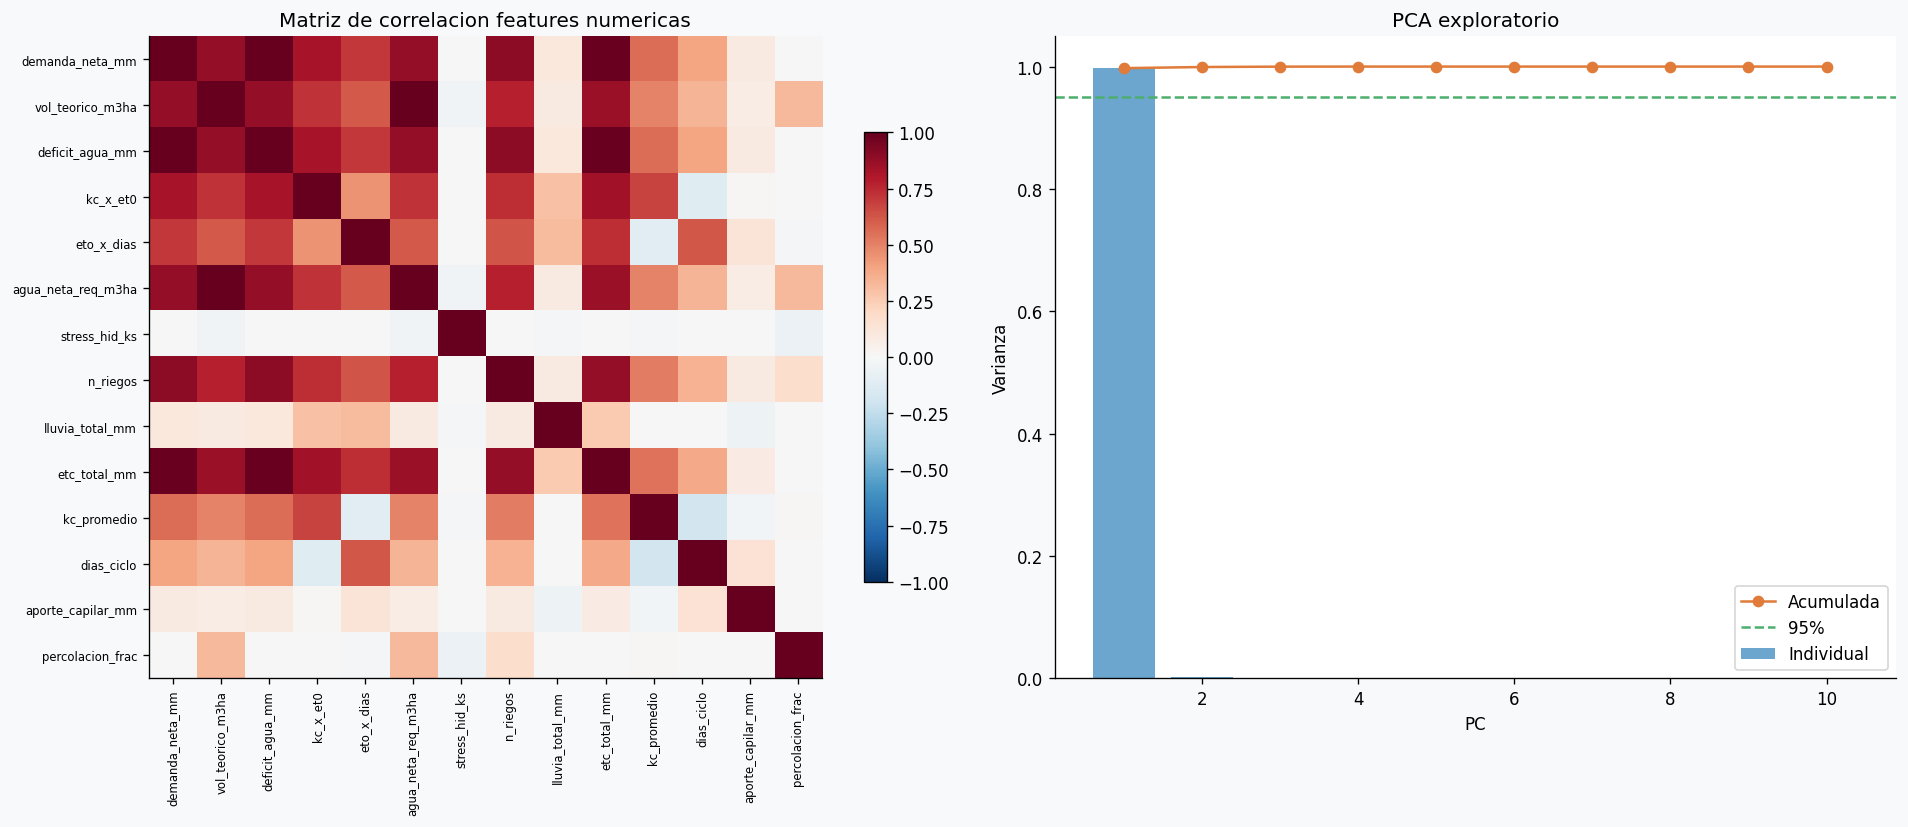

In [30]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=C_BG)

ax = axes[0]
n = len(NUM_AUDIT)
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(NUM_AUDIT, rotation=90, fontsize=7)
ax.set_yticklabels(NUM_AUDIT, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title('Matriz de correlacion features numericas')

ax2 = axes[1]
X_pca = df_s[NUM_AUDIT].fillna(0).values
pca = PCA(n_components=min(10, n), random_state=SEED)
pca.fit(X_pca)
var_exp = pca.explained_variance_ratio_.cumsum()
ax2.bar(range(1, len(var_exp)+1), pca.explained_variance_ratio_,
        color=C_AGUA, alpha=0.7, label='Individual')
ax2.plot(range(1, len(var_exp)+1), var_exp, 'o-', color=C_WARN, label='Acumulada')
ax2.axhline(0.95, color=C_REND, ls='--', label='95%')
ax2.set_xlabel('PC'); ax2.set_ylabel('Varianza'); ax2.set_title('PCA exploratorio')
ax2.legend()

plt.tight_layout(); plt.savefig('v4_corr_pca.png'); plt.show()
n95 = int((var_exp < 0.95).sum()) + 1
print(f'Componentes para 95% varianza: {n95}/{n} ({n95/n*100:.0f}%)')
print('Interpretacion: si n95 << n, hay alta multicolinealidad/redundancia.')


## ETAPA 1c — Baselines Dinamicos por Cultivo (fix para v4)

Reemplaza `BASELINE_AGUA=8000` / `RANGO_OP=[6k-10k]` con mediana y Q25-Q75 por cultivo.
Esto corrige el sesgo de evaluacion en Algodon (baseline real ~16k) y Frijol (~8k).

In [31]:
TARGET_COL = 'volumen_agua_total_m3_ha'

crop_stats_v4 = (
    df.groupby('cultivo')[TARGET_COL]
    .agg(
        baseline_m3ha = lambda x: x.median(),
        objetivo_m3ha = lambda x: x.median() * 0.75,
        op_min_q25    = lambda x: x.quantile(0.25),
        op_max_q75    = lambda x: x.quantile(0.75),
    )
    .round(0)
)
print('Baselines dinamicos v4:')
print(crop_stats_v4.to_string())

BASELINE_CROP_V4 = crop_stats_v4['baseline_m3ha'].to_dict()
OBJETIVO_CROP_V4 = crop_stats_v4['objetivo_m3ha'].to_dict()
OP_MIN_CROP_V4   = crop_stats_v4['op_min_q25'].to_dict()
OP_MAX_CROP_V4   = crop_stats_v4['op_max_q75'].to_dict()

# Sobreescribir globales con valores reales del dataset
BASELINE_AGUA = float(df[TARGET_COL].median())
OBJETIVO_AGUA = BASELINE_AGUA * 0.75
RANGO_OP_MIN  = float(df[TARGET_COL].quantile(0.25))
RANGO_OP_MAX  = float(df[TARGET_COL].quantile(0.75))

print(f'Global baseline: {BASELINE_AGUA:,.0f}  objetivo: {OBJETIVO_AGUA:,.0f}')
print(f'Global rango op: [{RANGO_OP_MIN:,.0f} - {RANGO_OP_MAX:,.0f}]')

def calc_weights_dynamic_v4(y_arr, cultivo_arr, w_op=3.0):
    w = np.ones(len(y_arr))
    for c in CULTIVOS:
        mask = cultivo_arr == c
        if not mask.any(): continue
        lo, hi = OP_MIN_CROP_V4[c], OP_MAX_CROP_V4[c]
        w[mask & (y_arr >= lo) & (y_arr <= hi)] = w_op
    return w

print('Funcion calc_weights_dynamic_v4 definida.')
